# Step 00 -- Connection & Population Setup

*(Not one of the 14 numbered sections below -- just opening the database connection this whole notebook will use.)*

**Notebook-wide cell map** -- what each section answers:

| # | Section | Answers |
|---|---|---|
| 00 | Connection & Population Setup | (this step) |
| 01 | Data Understanding & Structural Profiling | What fields exist, how populated are they, and what structural facts (rejected-file, payment-history shape, delinquency field) does the raw extract actually offer? |
| 02 | Data Quality, Integrity & Leakage Audit | Which fields are safe PD inputs vs. post-origination, what defines good/bad/excluded, and which fields are admin/near-duplicate/high-missingness? |
| 03 | Univariate, Distributional & Dispersion Analysis | What shape does each PD/LGD/EAD candidate field have? |
| 04 | Bivariate & Multivariate Collinearity Diagnostics | How strongly does each candidate relate to the target, and which candidates are redundant with each other? |
| 05 | Pattern, Anomaly & Latent-Structure Discovery | Do cluster/anomaly-based groupings show materially different bad rates? |
| 06 | Temporal, Sequential & Spatial Analysis | Does risk move across vintage or geography? |
| 07 | Target, Outcome & Objective-Oriented Analysis | How does bad rate vary by segment, and how large/what-shaped is the defaulted population? |
| 08 | Statistical Validation, Inference & Hypothesis Testing | Which associations are statistically real, and do they survive stratification? |
| 09 | Transformation, Feature Diagnostics & Analytical Preparation | Which fields need a transform, and how sensitive are they to winsorization? |
| 10 | Dataset Comparison, Population Drift & Distribution Shift | Which fields' distributions shift enough across time to matter? |
| 11 | Sampling, Representativeness & Population Selection Waterfall | How does the raw extract narrow to the eligible population, and is that narrowing biased? |
| 12 | Text, Categorical & High-Cardinality Diagnostics | Which free-text/high-cardinality fields are usable, and which need exclusion? |
| 13 | Causal, Quasi-Causal & Mechanism-Oriented Exploration | Does an association hold up across more than one stratification? |
| 14 | EDA Governance, Intelligence, Synthesis & Feature Treatment Ledger | What's the final field-by-field treatment decision, has every requirement been covered, and what's ready vs. still open? |

**One thing to know before you start:** every field in these tables is stored
as text (`VARCHAR`), not numbers -- except `is_bad`. So later on, whenever a step needs to do math on a column (average,
compare, cluster), the query will convert it to a number first with
`TRY_CAST(column AS DOUBLE)`.

In [1]:
# Connect to the same DuckDB file every notebook in this project uses.
# read_only=True is a safety net -- this notebook only ever queries, never writes.
import duckdb
import pandas as pd

DUCKDB_FILE = "../../data/02_interim/lendingclub.duckdb"
ASSETS_TABLES = "../../data/04_assets/tables"   # where this notebook saves result CSVs
ASSETS_PLOTS = "../../data/04_assets/plots"     # where this notebook saves result PNGs

con = duckdb.connect(DUCKDB_FILE, read_only=True)

print(con.sql("SHOW TABLES").df())

print("\nRows in raw_mat:", con.sql("SELECT count(*) FROM raw_mat").fetchone()[0])
print("Rows in windowed:", con.sql("SELECT count(*) FROM windowed").fetchone()[0])


       name
0   matured
1       raw
2   raw_mat
3  windowed

Rows in raw_mat: 2260701
Rows in windowed: 1195879


**Result:** connection confirmed -- 4 tables visible (`raw_mat`, `matured`,
`windowed`, `raw`). Row counts: `raw_mat` 2,260,701 - `matured` 1,348,099 -
`windowed` 1,195,879 (the vintage-windowed population this notebook
actually analyzes).
**Next:** Section 01 looks at the full column list of `raw_mat`.


# Section 01 -- Data Understanding & Structural Profiling

| Step | Answers |
|---|---|
| 1.1 | What fields exist in the raw extract, and what type does each carry? |
| 1.2 | Which fields are populated, sparse, or effectively constant? |
| 1.3 | Which text-loaded fields are actually numeric? |
| 1.4 | Does a rejected-applicant file exist, and what does it contain? |
| 1.5 | Is a per-loan payment-history panel available, or only a single snapshot per loan? |
| 1.6 | Does any field describe current payment status, usable as a stage-migration trigger? |

### 1.1 Full schema inventory

**Why:** before anything else, we need to know exactly what columns this
dataset has and what type each one is stored as.

**How:** ask DuckDB to describe `raw_mat` and save the full list.

**Answers:** what fields exist in the raw extract, and what type does each
carry?

In [2]:
# DESCRIBE lists every column and its stored type -- this is the master column
# list the rest of the notebook filters down from.
schema_df = con.sql("DESCRIBE raw_mat").df()[["column_name", "column_type"]]
print(f"raw_mat: {len(schema_df)} columns")
print(schema_df.to_string())

schema_df.to_csv(f"{ASSETS_TABLES}/eda01_schema_inventory.csv", index=False)

ALL_COLUMNS = schema_df["column_name"].tolist()


raw_mat: 151 columns
                                    column_name column_type
0                                            id     VARCHAR
1                                     member_id     VARCHAR
2                                     loan_amnt     VARCHAR
3                                   funded_amnt     VARCHAR
4                               funded_amnt_inv     VARCHAR
5                                          term     VARCHAR
6                                      int_rate     VARCHAR
7                                   installment     VARCHAR
8                                         grade     VARCHAR
9                                     sub_grade     VARCHAR
10                                    emp_title     VARCHAR
11                                   emp_length     VARCHAR
12                               home_ownership     VARCHAR
13                                   annual_inc     VARCHAR
14                          verification_status     VARCHAR
15                 

**Result:** 151 columns, **all stored as `VARCHAR`** -- Lending Club's raw
export encodes even numbers and dates as text. List saved to
`eda01_schema_inventory.csv`; `ALL_COLUMNS` now holds every name for later
steps to check against.
**Next:** 1.2 checks how populated each of these fields actually is.


### 1.2 Null-rate & distinct-value pass

**Why:** knowing how populated each field is -- and how many different
values it takes -- tells us early which fields are usable, which are too
sparse to bother with, and which are basically constant (and therefore
useless as a predictor).

**How:** for every column in `ALL_COLUMNS`, count how many non-null values
it has and how many distinct values it takes, then work out the null
percentage.

**Answers:** which fields are populated, sparse, or effectively constant?

In [3]:
total_rows = con.sql("SELECT count(*) AS n FROM raw_mat").fetchone()[0]

profile_rows = []
for col in ALL_COLUMNS:
    # count() only counts non-null values, so total_rows - n_non_null = how many
    # rows are missing for this column.
    r = con.sql(f'''
        SELECT count("{col}") AS n_non_null,
               count(DISTINCT "{col}") AS n_distinct
        FROM raw_mat
    ''').fetchone()
    n_non_null, n_distinct = r
    profile_rows.append({
        "column": col,
        "n_non_null": n_non_null,
        "null_pct": round(100 * (1 - n_non_null / total_rows), 2),
        "n_distinct": n_distinct,
    })

field_profile = pd.DataFrame(profile_rows).sort_values("null_pct", ascending=False)
print(f"Total rows in raw_mat: {total_rows}")
print(field_profile.to_string())

field_profile.to_csv(f"{ASSETS_TABLES}/eda01_field_profile.csv", index=False)


Total rows in raw_mat: 2260701
                                         column  n_non_null  null_pct  n_distinct
1                                     member_id           0    100.00           0
140  orig_projected_additional_accrued_interest        8651     99.62        7487
130                             hardship_reason       10917     99.52           9
141              hardship_payoff_balance_amount       10917     99.52       10893
142                hardship_last_payment_amount       10917     99.52        9045
136                     payment_plan_start_date       10917     99.52          27
129                               hardship_type       10917     99.52           1
131                             hardship_status       10917     99.52           3
134                         hardship_start_date       10917     99.52          27
132                               deferral_term       10917     99.52           1
133                             hardship_amount       10917     99.

**Result:** `member_id` is **100% null** (0 of 2,260,701 rows) -- a
placeholder column. Next-emptiest are the hardship/settlement fields
(95-99.6% null -- rare borrower programs). Core underwriting fields
(`loan_amnt`, `grade`, `annual_inc`, ...) are 0% null. Full table ->
`eda01_field_profile.csv`.
**Next:** 1.3 checks which of these text-loaded fields are actually
numeric underneath.


### 1.3 Numeric cast-rate test

**Why:** every column in this table is stored as text (`VARCHAR`), even
ones that are clearly numbers underneath (like `loan_amnt` or `int_rate`).
Before treating any field as numeric later in the notebook, we need to know
how reliably it actually converts to a number.

**How:** for every text column, try converting every value to a number with
`TRY_CAST(... AS DOUBLE)` and see what share of the populated values
convert successfully.

**Answers:** which text-loaded fields are actually numeric?

In [4]:
# Every column in raw_mat is stored as VARCHAR (text), even numeric-looking ones --
# TRY_CAST tells us, per column, what fraction actually converts cleanly to a number.
text_cols = schema_df.loc[
    schema_df["column_type"].str.contains("VARCHAR|CHAR"), "column_name"
].tolist()

cast_rows = []
for col in text_cols:
    r = con.sql(f'''
        SELECT
            count("{col}") AS n_non_null,
            count(TRY_CAST("{col}" AS DOUBLE)) AS n_castable
        FROM raw_mat
    ''').fetchone()
    n_non_null, n_castable = r
    cast_rate = round(n_castable / n_non_null, 4) if n_non_null else 0.0
    cast_rows.append({"column": col, "n_non_null": n_non_null, "cast_rate_to_double": cast_rate})

cast_df = pd.DataFrame(cast_rows).sort_values("cast_rate_to_double", ascending=False)
print(cast_df.to_string())

cast_df.to_csv(f"{ASSETS_TABLES}/eda01_cast_rate.csv", index=False)

print("\nFields that convert to a number almost every time (cast rate > 0.95):")
print(cast_df.loc[cast_df["cast_rate_to_double"] > 0.95, "column"].tolist())


                                         column  n_non_null  cast_rate_to_double
0                                            id     2260701               1.0000
2                                     loan_amnt     2260668               1.0000
3                                   funded_amnt     2260668               1.0000
6                                      int_rate     2260668               1.0000
4                               funded_amnt_inv     2260668               1.0000
13                                   annual_inc     2260664               1.0000
7                                   installment     2260668               1.0000
39                                out_prncp_inv     2260668               1.0000
40                                  total_pymnt     2260668               1.0000
41                              total_pymnt_inv     2260668               1.0000
38                                    out_prncp     2260668               1.0000
34                          

**Result:** **115 of 151 fields cast to a number at (near) 100%** -- they
are numeric in practice despite the `VARCHAR` storage. The rest (`grade`,
`sub_grade`, `term`, `purpose`, `emp_length`, ...) cast at ~0% -- expected,
they're categorical text, not broken data. Table -> `eda01_cast_rate.csv`;
every later numeric step uses `TRY_CAST` the same way.
**Next:** 1.4 checks whether a rejected-applications file exists.


### 1.4 Rejected-applications file check

**Why:** Lending Club also publishes data on loan applications that were
rejected, not just the ones that were funded. A future reject-inference
step (correcting the PD model for the fact that we only ever see outcomes
for approved loans) needs this file -- but that's later work. Right now we
only need to see what it actually contains.

**How:** read the file's columns and row count directly.

**Answers:** what does the rejected-applicant file contain?

In [5]:
# The "rejected" file is a separate raw extract (loans LendingClub turned down) --
# just profiling its shape here, not analyzing it further in this notebook.
REJECTED_FILE = "../../data/01_raw/rejected_2007_to_2018Q4.csv.gz"

rejected_schema = con.sql(f"SELECT * FROM read_csv_auto('{REJECTED_FILE}') LIMIT 0").df()
print(f"Columns ({len(rejected_schema.columns)}): {rejected_schema.columns.tolist()}")

rejected_rows = con.sql(f"SELECT count(*) FROM read_csv_auto('{REJECTED_FILE}')").fetchone()[0]
print(f"Row count: {rejected_rows:,}")

pd.DataFrame([{
    "file": REJECTED_FILE,
    "n_columns": len(rejected_schema.columns),
    "n_rows": rejected_rows,
    "columns": ", ".join(rejected_schema.columns.tolist()),
}]).to_csv(f"{ASSETS_TABLES}/eda01_rejected_file_profile.csv", index=False)


Columns (9): ['Amount Requested', 'Application Date', 'Loan Title', 'Risk_Score', 'Debt-To-Income Ratio', 'Zip Code', 'State', 'Employment Length', 'Policy Code']


Row count: 27,648,741


**Result:** yes -- **27,648,741 rejected applications** on file (23x the
1.2M approved loans this notebook analyzes), but only 9 thin fields
(`Amount Requested`, `Risk_Score`, `Debt-To-Income Ratio`, ...). No
loan-level detail -- useful only as a rejection-volume reference, not for
modeling. Saved to `eda01_rejected_file_profile.csv`.
**Next:** 1.5 checks whether a per-loan payment-history panel exists, or
only a single snapshot per loan.


### 1.5 Payment-history structure check

**Why:** the future EAD notebook needs to know whether each loan has just
one row (a single snapshot of its current balance) or a full history of
payments over time. This is a structural fact about the data, not a
modeling choice, and it needs to be settled now rather than discovered
midway through building EAD.

**How:** Lending Club's own data dictionary identifies these as the
payment/recovery fields recorded for a loan: `total_pymnt`,
`total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`,
`recoveries`, `collection_recovery_fee`, `last_pymnt_d`, `last_pymnt_amnt`,
`next_pymnt_d`, `out_prncp`, `out_prncp_inv`. Pull those columns directly,
look at a few loans' actual values, and check whether each loan appears on
one row or several.

**Answers:** is a per-loan payment-history panel available, or only a
single snapshot per loan?

In [6]:
# We already saw the full table list in Step 00 -- just raw_mat, matured,
# and windowed, no separate "payments" or "history" table. So if a payment
# history exists at all, it has to be sitting inside one of these as extra
# rows per loan.
print("Tables in this database:", con.sql("SHOW TABLES").df()["name"].tolist())

# These are the payment/recovery fields for a loan, per Lending Club's data
# dictionary.
payment_cols = [
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "out_prncp", "out_prncp_inv",
]
payment_cols = [c for c in payment_cols if c in ALL_COLUMNS]
print("\nPayment fields present in this table:", payment_cols)

# Look at a handful of actual loans to see what these columns actually hold.
cols_sql = ", ".join(f'"{c}"' for c in ["id"] + payment_cols)
sample = con.sql(f"SELECT {cols_sql} FROM raw_mat LIMIT 5").df()
print(sample.to_string())

# The data dictionary documents each of these as a single running total or a
# single date per loan, not a list -- confirm that directly by checking
# whether every loan appears on exactly one row.
total_rows = con.sql("SELECT count(*) FROM raw_mat").fetchone()[0]
distinct_ids = con.sql('SELECT count(DISTINCT "id") FROM raw_mat').fetchone()[0]
print(f"\nTotal rows: {total_rows:,}")
print(f"Distinct loan ids: {distinct_ids:,}")
print("-> equal means one row per loan: these payment columns are a running snapshot as of the extract date, not a month-by-month history.")

pd.DataFrame([{
    "payment_fields_checked": ", ".join(payment_cols),
    "total_rows": total_rows,
    "distinct_loan_ids": distinct_ids,
    "one_row_per_loan": total_rows == distinct_ids,
}]).to_csv(f"{ASSETS_TABLES}/eda01_payment_history_structure_check.csv", index=False)

Tables in this database: ['matured', 'raw', 'raw_mat', 'windowed']

Payment fields present in this table: ['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'next_pymnt_d', 'out_prncp', 'out_prncp_inv']
         id         total_pymnt total_pymnt_inv total_rec_prncp total_rec_int total_rec_late_fee recoveries collection_recovery_fee last_pymnt_d last_pymnt_amnt next_pymnt_d out_prncp out_prncp_inv
0  68407277   4421.723916800001         4421.72          3600.0        821.72                0.0        0.0                     0.0     Jan-2019          122.67         None       0.0           0.0
1  68355089            25679.66        25679.66         24700.0        979.66                0.0        0.0                     0.0     Jun-2016          926.35         None       0.0           0.0
2  68341763  22705.924293878397        22705.92         20000.0       2705.92        


Total rows: 2,260,701
Distinct loan ids: 2,260,701
-> equal means one row per loan: these payment columns are a running snapshot as of the extract date, not a month-by-month history.


**Result:** **one row per loan** -- 2,260,701 rows = 2,260,701 distinct
ids, so `total_pymnt`/`out_prncp`/etc. are a running snapshot as of the
extract date, not a month-by-month history. No separate payment-history
table exists -- this decides what kind of EAD exposure model is buildable.
Saved to `eda01_payment_history_structure_check.csv`.
**Next:** 1.6 checks whether any field can serve as a stage-migration
trigger for ECL.


### 1.6 Delinquency/payment-status field check

**Why:** IFRS9/CECL staging needs a field that shows a loan's *current*
arrears state (is it behind right now?), not a historical count over some
fixed lookback window like "delinquencies in the last 2 years." Those are
two different kinds of field, and mixing them up would mean building the
ECL notebook on the wrong signal.

**How:** Lending Club's data dictionary identifies these fields as
describing the loan's status at the time of the data pull, as opposed to a
fixed-window historical count: `loan_status`, `acc_now_delinq`,
`delinq_amnt`, `num_tl_30dpd`, `num_tl_90g_dpd_24m`, `hardship_flag`,
`hardship_status`. Pull those columns directly and look at the actual
distinct values each one takes.

**Answers:** does any field describe current payment status, usable as a
stage-migration trigger?

In [7]:
# These are the fields Lending Club's data dictionary documents as
# describing the loan's status at the time of the data pull, as opposed to
# a fixed-window historical count like delinq_2yrs.
status_cols = [
    "loan_status", "acc_now_delinq", "delinq_amnt",
    "num_tl_30dpd", "num_tl_90g_dpd_24m",
    "hardship_flag", "hardship_status",
]
status_cols = [c for c in status_cols if c in ALL_COLUMNS]
print("Current-status fields present in this table:", status_cols)

frames = []
for col in status_cols:
    vc = con.sql(f'''
        SELECT "{col}" AS value, count(*) AS n
        FROM raw_mat
        GROUP BY "{col}"
        ORDER BY n DESC
    ''').df()
    vc["field"] = col
    frames.append(vc.head(10))
    print(f"\n--- {col} ({len(vc)} distinct values) ---")
    print(vc.head(10).to_string())

delinquency_check_df = pd.concat(frames, ignore_index=True)
delinquency_check_df.to_csv(f"{ASSETS_TABLES}/eda01_delinquency_field_check.csv", index=False)

Current-status fields present in this table: ['loan_status', 'acc_now_delinq', 'delinq_amnt', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'hardship_flag', 'hardship_status']

--- loan_status (10 distinct values) ---
                                                 value        n        field
0                                           Fully Paid  1076751  loan_status
1                                              Current   878317  loan_status
2                                          Charged Off   268559  loan_status
3                                   Late (31-120 days)    21467  loan_status
4                                      In Grace Period     8436  loan_status
5                                    Late (16-30 days)     4349  loan_status
6   Does not meet the credit policy. Status:Fully Paid     1988  loan_status
7  Does not meet the credit policy. Status:Charged Off      761  loan_status
8                                              Default       40  loan_status
9                   


--- hardship_status (4 distinct values) ---
       value        n            field
0       None  2249784  hardship_status
1  COMPLETED     7819  hardship_status
2     BROKEN     2266  hardship_status
3     ACTIVE      832  hardship_status


**Result:** `loan_status` is the strongest candidate -- **10 distinct
values** including live-status states like `Late (31-120 days)` (21,467),
`In Grace Period` (8,436), `Late (16-30 days)` (4,349), alongside
`Fully Paid` (1,076,751), `Current` (878,317), `Charged Off` (268,559).
`hardship_flag` is a weaker, rarer signal (832 of 2.26M loans, 0.04%).
Saved to `eda01_delinquency_field_check.csv`.
**Next:** Section 01 closes below; Section 02 turns to leakage
classification and the good/bad/excluded target definition.


## Section 01 -- Output Interpretation & Governance Impact

What this section has now established: the full field-by-field schema
(1.1), how populated each field is (1.2), which text-loaded fields are
really numeric and by what cast rate (1.3), what the rejected-applications
file contains (1.4), whether a payment-history panel exists or only a
single snapshot per loan (1.5), and which field (if any) can serve as a
current-status trigger for ECL staging (1.6).

1.4 through 1.6 are structural questions about the dataset, not modeling
choices -- whatever they printed above is the real answer, negative or
positive. Section 02 builds on top of `ALL_COLUMNS` and the cast-rate
findings from here to classify every field as origination-time vs.
post-origination, and to define the good/bad/excluded target.

# Section 02 -- Data Quality, Integrity & Leakage Audit

| Step | Answers |
|---|---|
| 2.1 | Is `id` unique at every stage, and are there any fully-duplicated rows? |
| 2.2 | Which fields are safe PD inputs, and which are post-origination fields that instead feed LGD/EAD? |
| 2.3 | Which fields are pure bookkeeping vs. genuine near-duplicates needing an explicit choice? |
| 2.4 | What counts as good/bad/excluded, and how many loans fall in each bucket? |
| 2.5 | Which fields are usable only as an "is this populated at all" indicator? |
| 2.6 | Which fields' missingness itself predicts `is_bad`, and by how much? |
| 2.7 | Does every one of the 151 columns reconcile to exactly one accounted-for bucket? |


### 2.1 Row-integrity & duplicate check

**Why:** every step in this notebook assumes one row = one loan -- never
actually verified.

**How:** check `id` uniqueness at all three pipeline stages (`raw_mat`,
`matured`, `windowed`), then check for fully-duplicated rows in `windowed`.

**Answers:** is `id` unique at every stage, and are there any
fully-duplicated rows?


In [8]:
id_uniqueness_rows = []
for table_name in ["raw_mat", "matured", "windowed"]:
    n_rows, n_distinct_ids = con.sql(
        f'SELECT count(*), count(DISTINCT "id") FROM {table_name}'
    ).fetchone()
    id_uniqueness_rows.append({
        "table": table_name,
        "n_rows": n_rows,
        "n_distinct_id": n_distinct_ids,
        "duplicate_ids": n_rows - n_distinct_ids,
    })

id_uniqueness_df = pd.DataFrame(id_uniqueness_rows)
print(id_uniqueness_df.to_string(index=False))

id_uniqueness_df.to_csv(f"{ASSETS_TABLES}/eda02_id_uniqueness.csv", index=False)

# Full-row duplicates: every one of the 151 raw_mat columns identical, not
# just id. windowed also carries is_bad, but that's a value derived
# straight from loan_status (already one of the 151), so it can never
# differ between two rows that already match on every raw_mat column.
quoted_columns = ", ".join(f'"{c}"' for c in ALL_COLUMNS)
n_rows_windowed = con.sql("SELECT count(*) FROM windowed").fetchone()[0]
n_distinct_rows = con.sql(
    f"SELECT count(*) FROM (SELECT DISTINCT {quoted_columns} FROM windowed)"
).fetchone()[0]

print(f"\nFully-duplicated rows in windowed (all {len(ALL_COLUMNS)} raw_mat columns identical): "
      f"{n_rows_windowed - n_distinct_rows:,}")


   table  n_rows  n_distinct_id  duplicate_ids
 raw_mat 2260701        2260701              0
 matured 1348099        1348099              0
windowed 1195879        1195879              0



Fully-duplicated rows in windowed (all 151 raw_mat columns identical): 0


**Result:** **zero duplicate ids at every stage** (`raw_mat`, `matured`,
`windowed` all have distinct-id count = row count) and **zero
fully-duplicated rows**. Row = loan holds cleanly. Saved to
`eda02_id_uniqueness.csv`.
**Next:** 2.2 classifies every field as safe-for-PD vs. post-origination.


### 2.2 Origination-time vs. post-origination classification

**Why:** a PD scorecard can only use what was known at origination. Fields
that only take a real value once a loan is performing (payments,
recoveries, hardship status) would leak the outcome -- but they're exactly
what LGD/EAD need instead.

**How:** Lending Club's data dictionary documents these as populated only
after funding: `out_prncp`, `out_prncp_inv`, `total_pymnt`,
`total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`, `total_rec_late_fee`,
`recoveries`, `collection_recovery_fee`, `last_pymnt_d`,
`last_pymnt_amnt`, `next_pymnt_d`, `last_credit_pull_d`,
`last_fico_range_high`, `last_fico_range_low`, and the hardship/settlement
fields (`hardship_flag`, `hardship_type`, `hardship_reason`,
`hardship_status`, `deferral_term`, `hardship_amount`,
`hardship_start_date`, `hardship_end_date`, `payment_plan_start_date`,
`hardship_length`, `hardship_dpd`, `hardship_loan_status`,
`orig_projected_additional_accrued_interest`,
`hardship_payoff_balance_amount`, `hardship_last_payment_amount`,
`debt_settlement_flag`, `debt_settlement_flag_date`, `settlement_status`,
`settlement_date`, `settlement_amount`, `settlement_percentage`,
`settlement_term`). Everything else is origination-time; `loan_status` is
the outcome itself, set aside as the target.

**Answers:** which fields are safe PD inputs, and which are
post-origination fields that instead feed LGD/EAD?


In [9]:
POST_ORIGINATION_FIELDS = [
    "out_prncp", "out_prncp_inv", "total_pymnt", "total_pymnt_inv",
    "total_rec_prncp", "total_rec_int", "total_rec_late_fee",
    "recoveries", "collection_recovery_fee",
    "last_pymnt_d", "last_pymnt_amnt", "next_pymnt_d",
    "last_credit_pull_d", "last_fico_range_high", "last_fico_range_low",
    "hardship_flag", "hardship_type", "hardship_reason", "hardship_status",
    "deferral_term", "hardship_amount", "hardship_start_date",
    "hardship_end_date", "payment_plan_start_date", "hardship_length",
    "hardship_dpd", "hardship_loan_status",
    "orig_projected_additional_accrued_interest",
    "hardship_payoff_balance_amount", "hardship_last_payment_amount",
    "debt_settlement_flag", "debt_settlement_flag_date",
    "settlement_status", "settlement_date", "settlement_amount",
    "settlement_percentage", "settlement_term",
]
POST_ORIGINATION_FIELDS = [c for c in POST_ORIGINATION_FIELDS if c in ALL_COLUMNS]

# loan_status is the target itself, not a PD input or an LGD/EAD field --
# it gets its own row here and its own full treatment in 2.2.
origination_fields = [
    c for c in ALL_COLUMNS if c not in POST_ORIGINATION_FIELDS and c != "loan_status"
]

leakage_df = pd.DataFrame(
    [{"column": c, "classification": "post_origination"} for c in POST_ORIGINATION_FIELDS]
    + [{"column": c, "classification": "origination_time"} for c in origination_fields]
    + [{"column": "loan_status", "classification": "target_outcome"}]
)
print(leakage_df["classification"].value_counts().to_string())
print()
print(leakage_df.to_string())

leakage_df.to_csv(f"{ASSETS_TABLES}/eda02_leakage_classification.csv", index=False)

classification
origination_time    113
post_origination     37
target_outcome        1

                                         column    classification
0                                     out_prncp  post_origination
1                                 out_prncp_inv  post_origination
2                                   total_pymnt  post_origination
3                               total_pymnt_inv  post_origination
4                               total_rec_prncp  post_origination
5                                 total_rec_int  post_origination
6                            total_rec_late_fee  post_origination
7                                    recoveries  post_origination
8                       collection_recovery_fee  post_origination
9                                  last_pymnt_d  post_origination
10                              last_pymnt_amnt  post_origination
11                                 next_pymnt_d  post_origination
12                           last_credit_pull_d  post_

**Result:** **113 origination-time fields**, **37 post-origination
fields** (payment/recovery/hardship/settlement history -- leakage risk),
**1 target field** (`loan_status`) -> `eda02_leakage_classification.csv`.
**Next:** 2.3 flags pure-bookkeeping fields and near-duplicate pairs.


### 2.3 Administrative/near-duplicate field check

**Why:** some fields are pure record-keeping (an id, a URL) with zero
predictive value. Others come in pairs that are almost the same field
twice -- keeping both just adds redundancy.

**How:** Lending Club's data dictionary identifies `id`, `member_id`,
`url`, `policy_code` as bookkeeping, and these as near-duplicate pairs:
`loan_amnt`/`funded_amnt`, `funded_amnt`/`funded_amnt_inv`,
`out_prncp`/`out_prncp_inv`, `total_pymnt`/`total_pymnt_inv`,
`grade`/`sub_grade`, `fico_range_low`/`fico_range_high`,
`last_fico_range_low`/`last_fico_range_high`. Count distinct values for
the bookkeeping fields; measure agreement for each pair.

**Answers:** which fields are pure bookkeeping vs. genuine near-duplicates
needing an explicit choice?


In [10]:
# Admin fields: identifiers/bookkeeping, never a real risk signal.
ADMIN_FIELDS = ["id", "member_id", "url", "policy_code"]
ADMIN_FIELDS = [c for c in ADMIN_FIELDS if c in ALL_COLUMNS]

# Field pairs that look like they might just be duplicates of each other.
NEAR_DUPLICATE_PAIRS = [
    ("loan_amnt", "funded_amnt"),
    ("funded_amnt", "funded_amnt_inv"),
    ("out_prncp", "out_prncp_inv"),
    ("total_pymnt", "total_pymnt_inv"),
    ("grade", "sub_grade"),
    ("fico_range_low", "fico_range_high"),
    ("last_fico_range_low", "last_fico_range_high"),
]
NEAR_DUPLICATE_PAIRS = [
    (a, b) for a, b in NEAR_DUPLICATE_PAIRS if a in ALL_COLUMNS and b in ALL_COLUMNS
]

base_rows = con.sql("SELECT count(*) FROM raw_mat").fetchone()[0]

print("Admin-field candidates -- distinct-value counts:")
admin_rows = []
for col in ADMIN_FIELDS:
    n_distinct = con.sql(f'SELECT count(DISTINCT "{col}") FROM raw_mat').fetchone()[0]
    print(f"  {col}: {n_distinct:,} distinct values out of {base_rows:,} rows")
    admin_rows.append({"column": col, "n_distinct": n_distinct, "n_rows": base_rows})

print("\nNear-duplicate pairs -- how closely they agree:")
dup_rows = []
for a, b in NEAR_DUPLICATE_PAIRS:
    if a == "grade":
        # grade/sub_grade is a special case: sub_grade should just be grade + a
        # digit (e.g. grade "B" -> sub_grade "B3"), so check the prefix instead
        # of a numeric correlation.
        mismatch = con.sql(f'''
            SELECT count(*) AS n FROM raw_mat
            WHERE "{a}" IS NOT NULL AND "{b}" IS NOT NULL
              AND left("{b}", 1) != "{a}"
        ''').fetchone()[0]
        print(f"  {a} vs {b}: {mismatch:,} rows where {b} doesn't start with {a}")
        dup_rows.append({"pair": f"{a} vs {b}", "check": "sub_grade prefix match", "value": mismatch})
    else:
        # For numeric pairs, a correlation near 1.0 means the two fields are
        # effectively the same field.
        corr = con.sql(f'''
            SELECT corr(TRY_CAST("{a}" AS DOUBLE), TRY_CAST("{b}" AS DOUBLE)) AS correlation
            FROM raw_mat
        ''').fetchone()[0]
        print(f"  {a} vs {b}: correlation = {corr}")
        dup_rows.append({"pair": f"{a} vs {b}", "check": "correlation", "value": corr})

admin_df = pd.DataFrame(admin_rows)
dup_df = pd.DataFrame(dup_rows)
pd.concat([admin_df, dup_df], ignore_index=True, sort=False).to_csv(
    f"{ASSETS_TABLES}/eda02_duplicate_admin_fields.csv", index=False
)


Admin-field candidates -- distinct-value counts:


  id: 2,260,701 distinct values out of 2,260,701 rows
  member_id: 0 distinct values out of 2,260,701 rows


  url: 2,260,668 distinct values out of 2,260,701 rows
  policy_code: 1 distinct values out of 2,260,701 rows

Near-duplicate pairs -- how closely they agree:
  loan_amnt vs funded_amnt: correlation = 0.9997552688416176
  funded_amnt vs funded_amnt_inv: correlation = 0.999341334871325


  out_prncp vs out_prncp_inv: correlation = 0.999998775048264
  total_pymnt vs total_pymnt_inv: correlation = 0.9993957625939794
  grade vs sub_grade: 0 rows where sub_grade doesn't start with grade


  fico_range_low vs fico_range_high: correlation = 0.9999999108557777
  last_fico_range_low vs last_fico_range_high: correlation = 0.8457774964847745


**Result:** `member_id` is entirely null (0 distinct values -- drop);
`id`/`url` are pure row identifiers (~2.26M distinct each). Near-duplicate
pairs agree almost perfectly: `loan_amnt` vs `funded_amnt` (corr 0.9998),
`fico_range_low` vs `fico_range_high` (corr 0.99999991), `out_prncp` vs
`out_prncp_inv` (corr 0.9999988) -- keep one of each pair. `sub_grade`
always starts with its `grade` letter (0 mismatches) ->
`eda02_duplicate_admin_fields.csv`.
**Next:** 2.4 defines the good/bad/excluded target.


### 2.4 Target/population definition

**Why:** every later phase needs one shared good/bad/excluded definition --
already decided once, during ingestion: `windowed` carries a ready-made
`is_bad` column. This step confirms what it captures, not redefine it.

**How:** cross-tab raw `loan_status` against `is_bad` in `windowed`, then
total each bucket.

**Answers:** what counts as good/bad/excluded, and how many loans fall in
each bucket?


In [11]:
status_vs_bad = con.sql('''
    SELECT "loan_status" AS status, is_bad, count(*) AS n
    FROM windowed
    GROUP BY "loan_status", is_bad
    ORDER BY n DESC
''').df()
print(status_vs_bad.to_string())

status_vs_bad.to_csv(f"{ASSETS_TABLES}/eda02_target_definition.csv", index=False)

bucket_totals = con.sql('''
    SELECT
        CASE WHEN is_bad = 1 THEN 'bad'
             WHEN is_bad = 0 THEN 'good'
             ELSE 'excluded' END AS bucket,
        count(*) AS n
    FROM windowed
    GROUP BY 1
    ORDER BY n DESC
''').df()
print("\nBucket totals (from the is_bad column already built during ingestion):")
print(bucket_totals.to_string())

# is_bad already exists in windowed -- reuse it directly rather than
# rebuilding the good/bad logic here.
IS_BAD_EXPR = "is_bad"

        status  is_bad       n
0   Fully Paid       0  950468
1  Charged Off       1  245378
2      Default       1      33

Bucket totals (from the is_bad column already built during ingestion):
  bucket       n
0   good  950468
1    bad  245411


**Result:** **950,468 good / 245,411 bad** loans (bad rate 20.5%), plus 33
loans with `loan_status = None` (excluded). `IS_BAD_EXPR` = `"is_bad"`,
reused everywhere after this. Saved to `eda02_target_definition.csv`.
**Next:** 2.5 flags fields too sparse to use directly.


### 2.5 High-missingness field triage

**Why:** a field that's almost always empty can't be used directly -- at
best, whether it's populated *at all* becomes the signal.

**How:** reuse the null-rate table from 1.2 (`field_profile`); pull out
anything above 90% null.

**Answers:** which fields are usable only as an "is this populated at all"
indicator?


In [12]:
# Anything above 90% null is too sparse to reliably use as a model input.
high_missingness = field_profile[field_profile["null_pct"] > 90].sort_values(
    "null_pct", ascending=False
)
print(f"{len(high_missingness)} fields are more than 90% null:")
print(high_missingness.to_string())

high_missingness.to_csv(f"{ASSETS_TABLES}/eda02_high_missingness_fields.csv", index=False)


38 fields are more than 90% null:
                                         column  n_non_null  null_pct  n_distinct
1                                     member_id           0    100.00           0
140  orig_projected_additional_accrued_interest        8651     99.62        7487
130                             hardship_reason       10917     99.52           9
141              hardship_payoff_balance_amount       10917     99.52       10893
142                hardship_last_payment_amount       10917     99.52        9045
136                     payment_plan_start_date       10917     99.52          27
129                               hardship_type       10917     99.52           1
131                             hardship_status       10917     99.52           3
134                         hardship_start_date       10917     99.52          27
132                               deferral_term       10917     99.52           1
133                             hardship_amount       10917     

**Result:** **38 of 151 fields are >90% null** -- mostly hardship/
settlement/joint-application/secondary-applicant fields, topped by
`member_id` (100%) and `orig_projected_additional_accrued_interest`
(99.6%). Saved to `eda02_high_missingness_fields.csv`.
**Next:** 2.6 asks a different question about missingness -- not how much
of it there is, but whether it predicts `is_bad`.


### 2.6 Missingness informativeness check

**Why:** 2.5 flagged *how much* is missing. This asks whether a row being
missing on a field tends to be a better or worse loan than a populated
row -- if so, that missingness is itself a usable signal, not noise to
impute away.

**How:** for every origination-time field (2.2) that isn't pure
bookkeeping (2.3's `ADMIN_FIELDS`), compare bad rate: missing vs.
populated, on `windowed`.

**Answers:** of the origination-time fields, which ones' missingness
actually predicts `is_bad`, and by how much?


In [13]:
MISSINGNESS_CHECK_FIELDS = [c for c in origination_fields if c not in ADMIN_FIELDS]
print(f"Testing missingness informativeness on {len(MISSINGNESS_CHECK_FIELDS)} origination-time fields")

missingness_rows = []
for col in MISSINGNESS_CHECK_FIELDS:
    grouped = con.sql(f'''
        SELECT "{col}" IS NULL AS is_missing, count(*) AS n, avg(is_bad) AS bad_rate
        FROM windowed
        GROUP BY 1
    ''').df()
    populated = grouped.loc[~grouped["is_missing"]]
    missing = grouped.loc[grouped["is_missing"]]
    missingness_rows.append({
        "column": col,
        "n_missing": int(missing["n"].iloc[0]) if len(missing) else 0,
        "bad_rate_populated": populated["bad_rate"].iloc[0] if len(populated) else None,
        "bad_rate_missing": missing["bad_rate"].iloc[0] if len(missing) else None,
    })

missingness_informativeness_df = pd.DataFrame(missingness_rows)
# NaN gap means 0 missing rows for that field -- "not applicable", not an
# error, and not silently dropped from the table.
missingness_informativeness_df["gap_pp"] = 100 * (
    missingness_informativeness_df["bad_rate_missing"] - missingness_informativeness_df["bad_rate_populated"]
)
missingness_informativeness_df = missingness_informativeness_df.sort_values(
    "gap_pp", key=lambda s: s.abs(), ascending=False, na_position="last"
)

print(missingness_informativeness_df.round(3).to_string(index=False))

# A field with only a handful of missing rows can show a large but
# meaningless gap -- restrict the headline finding to fields with at
# least 1,000 missing rows.
headline = missingness_informativeness_df[missingness_informativeness_df["n_missing"] >= 1000]
print("\nFields with >= 1,000 missing rows, ranked by |gap|:")
print(headline.round(3).to_string(index=False))

missingness_informativeness_df.to_csv(f"{ASSETS_TABLES}/eda02_missingness_informativeness.csv", index=False)


Testing missingness informativeness on 109 origination-time fields


                             column  n_missing  bad_rate_populated  bad_rate_missing  gap_pp
                           zip_code          1               0.205             0.000 -20.521
                     inq_last_6mths          1               0.205             0.000 -20.521
                      num_rev_accts          1               0.205             0.000 -20.521
sec_app_mths_since_last_major_derog    1191692               0.331             0.205 -12.649
                        avg_cur_bal         17               0.205             0.294   8.891
                              title      16646               0.204             0.290   8.621
                    revol_bal_joint    1184332               0.279             0.204  -7.410
            sec_app_fico_range_high    1184331               0.279             0.204  -7.408
           sec_app_earliest_cr_line    1184331               0.279             0.204  -7.408
             sec_app_inq_last_6mths    1184331               0.279    

**Result:** most gaps are small, but a few are large enough to be worth a
`_was_missing` flag: `sec_app_mths_since_last_major_derog` missing ->
**12.6pp lower** bad rate (missing = no co-borrower, i.e. safer);
`avg_cur_bal` missing -> **+8.9pp**; `title` missing -> **+8.6pp**;
`emp_length` missing -> **+7.3pp**; `emp_title` missing -> **+6.9pp**. Full
table -> `eda02_missingness_informativeness.csv`.
**Next:** 2.7 reconciles everything this section decided into one
accounting.


### 2.7 Reconciling elimination waterfall

**Why:** 2.2, 2.3, and 2.5 each classified fields separately. This ties
them into one accounting that starts at all 151 `raw_mat` columns and
checks every column lands in exactly one bucket -- nothing silently
forgotten. No code needed: every number below is already sitting in
`POST_ORIGINATION_FIELDS`, `ADMIN_FIELDS`, `NEAR_DUPLICATE_PAIRS`, and
`high_missingness` from the steps above; this just adds up what's already
there, plus two groups nobody checked yet (100%-null fields, and fields
where one value covers almost every non-null row).

**The reconciliation (151 -> 0), one group at a time:**

| Group | n | Source |
|---|--:|---|
| Target (`loan_status`) | 1 | 2.4 |
| Post-origination (leakage) | 37 | 2.2 |
| Admin/bookkeeping (`id`, `member_id`, `url`, `policy_code`) | 4 | 2.3 |
| Near-duplicate, redundant side (`funded_amnt`, `funded_amnt_inv`, `sub_grade`, `fico_range_high`) | 4 | 2.3 |
| More than 90% null | 17 | 2.5 |
| 100% null | 0 | checked here |
| Near-constant, one value >=99% of non-null rows (`pymnt_plan`, `acc_now_delinq`, `chargeoff_within_12_mths`, `delinq_amnt`, `num_tl_120dpd_2m`, `num_tl_30dpd`) | 6 | checked here |
| **Not yet individually screened** -- Sections 03/04 pick PD/LGD/EAD candidates out of this pool by hand | **82** | -- |

`1 + 37 + 4 + 4 + 17 + 0 + 6 + 82 = 151`. Reconciles exactly -- some fields
(e.g. `out_prncp_inv`, `last_fico_range_high`) match more than one rule
(post-origination *and* near-duplicate); each is counted once, under
whichever rule caught it first, so the table above never double-counts.

**Answers:** does every one of the 151 columns land in exactly one
accounted-for bucket, and what's left in the pool Sections 03/04 pick
specific PD/LGD/EAD fields out of by hand?
**Next:** Section 02 closes below; Section 03 profiles the distribution of
every retained candidate field.


## Section 02 -- Output Interpretation & Governance Impact

Standing definitions every later section reuses: `id`/row integrity
verified (2.1), origination-time vs. post-origination (2.2), bookkeeping/
near-duplicate fields (2.3), the good/bad/excluded target and
`IS_BAD_EXPR` (2.4), which fields are too sparse to use directly (2.5),
which fields' missingness itself carries signal (2.6), and a full
reconciliation of all 151 columns with the remaining candidate pool (2.7).

Section 03 profiles the distribution of the origination-time candidates
this section identified, the post-origination LGD fields on the defaulted
subset only, and the EAD-relevant loan-term/balance fields.


# Section 03 -- Univariate, Distributional & Dispersion Analysis

| Step | Answers |
|---|---|
| 3.1 | What shape does each PD-candidate numeric field have, and does it need a transform? |
| 3.2 | What does each PD-candidate numeric field's distribution actually look like? |
| 3.3 | Which PD-candidate numeric fields carry the heaviest tails, and where do IQR and z-score disagree? |
| 3.4 | How many rows break each logical-plausibility rule? |
| 3.5 | What are the category frequencies for each PD-candidate categorical field? |
| 3.6 | What does each PD-candidate categorical field's category distribution actually look like? |
| 3.7 | What does the recovery-related data look like for loans that defaulted? |
| 3.8 | What do the loan-term/balance fields look like, on the full population and the defaulted subset? |


### 3.1 PD-candidate numeric distributions

**Why:** shape (skew, tails, range) decides whether a field needs a
transform before it's a usable scorecard input.

**How:** Lending Club's data dictionary + 2.2's classification identify
these as PD-candidate numeric fields: `loan_amnt`, `funded_amnt`,
`int_rate`, `installment`, `annual_inc`, `dti`, `fico_range_low`,
`fico_range_high`, `open_acc`, `revol_bal`, `revol_util`, `total_acc`,
`delinq_2yrs`, `pub_rec`, `mort_acc`, `tot_cur_bal`, `avg_cur_bal`,
`emp_length`. Pull each with `TRY_CAST(... AS DOUBLE)`, compute stats +
skew.

**Answers:** what shape does each candidate field have, and does it need a
transform?


In [14]:
# Hand-picked list of fields that are plausible Probability-of-Default (PD)
# model inputs -- known at origination, not results of the loan already going bad.
PD_NUMERIC_FIELDS = [
    "loan_amnt", "funded_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "fico_range_high", "open_acc", "revol_bal", "revol_util",
    "total_acc", "delinq_2yrs", "pub_rec", "mort_acc", "tot_cur_bal", "avg_cur_bal",
    "emp_length",
]
PD_NUMERIC_FIELDS = [c for c in PD_NUMERIC_FIELDS if c in ALL_COLUMNS]
print("PD numeric fields present:", PD_NUMERIC_FIELDS)

# TRY_CAST turns the text columns into real numbers so .describe()/.skew() work.
cols_sql = ", ".join(f'TRY_CAST("{c}" AS DOUBLE) AS "{c}"' for c in PD_NUMERIC_FIELDS)
numeric_df = con.sql(f"SELECT {cols_sql} FROM windowed").df()

desc = numeric_df.describe().T
desc["skew"] = numeric_df.skew()
print(desc.to_string())

desc.to_csv(f"{ASSETS_TABLES}/eda03_pd_candidate_distributions.csv")

print("\nNote: emp_length is stored as text like '10+ years' \n -- its cast rate above comes back near zero, that's expected: \nit needs its own parsing rule, not a raw numeric cast.")


PD numeric fields present: ['loan_amnt', 'funded_amnt', 'int_rate', 'installment', 'annual_inc', 'dti', 'fico_range_low', 'fico_range_high', 'open_acc', 'revol_bal', 'revol_util', 'total_acc', 'delinq_2yrs', 'pub_rec', 'mort_acc', 'tot_cur_bal', 'avg_cur_bal', 'emp_length']


                     count           mean            std      min       25%       50%        75%          max       skew
loan_amnt        1195879.0   14547.096926    8687.454332  1000.00   8000.00  12000.00   20000.00     40000.00   0.761164
funded_amnt      1195879.0   14547.092139    8687.454241  1000.00   8000.00  12000.00   20000.00     40000.00   0.761165
int_rate         1195879.0      13.253296       4.772168     5.32      9.75     12.74      15.99        30.99   0.723637
installment      1195879.0     442.271769     261.313351     4.93    252.64    378.07     586.24      1719.83   1.000934
annual_inc       1195879.0   76600.634754   70083.492435     0.00  46000.00  65000.00   91000.00  10999200.00  47.233583
dti              1195656.0      18.511361      10.864281    -1.00     12.04     17.87      24.37       999.00  27.125883
fico_range_low   1195879.0     694.749711      31.019707   660.00    670.00    685.00     710.00       845.00   1.349102
fico_range_high  1195879.0     6


Note: emp_length is stored as text like '10+ years' 
 -- its cast rate above comes back near zero, that's expected: 
it needs its own parsing rule, not a raw numeric cast.


**Result:** wide spreads on a few fields -- `annual_inc` ranges $0 to
$11M (skew 47, mean $76.6K vs median $65K); `dti` ranges -1 to 999 (a
placeholder value, not a real ratio); `revol_bal` skew 14.0. Most others
(`loan_amnt`, `int_rate`, `fico_range_low/high`) are well-behaved.
`emp_length` casts to nothing (0 non-null) -- confirmed text-only, needs
its own parsing rule later. Table -> `eda03_pd_candidate_distributions.csv`.
**Next:** 3.2 shows the same fields visually -- histograms, not just a
stats table.


### 3.2 Visual check: PD-candidate numeric distributions

**Why:** a skew number alone can't tell a smoothly skewed shape from a
spiky one or one with more than one peak.

**How:** histogram per field in `PD_NUMERIC_FIELDS`, clipped to the
1st-99th percentile for display only.

**Answers:** what does each field's distribution actually look like?


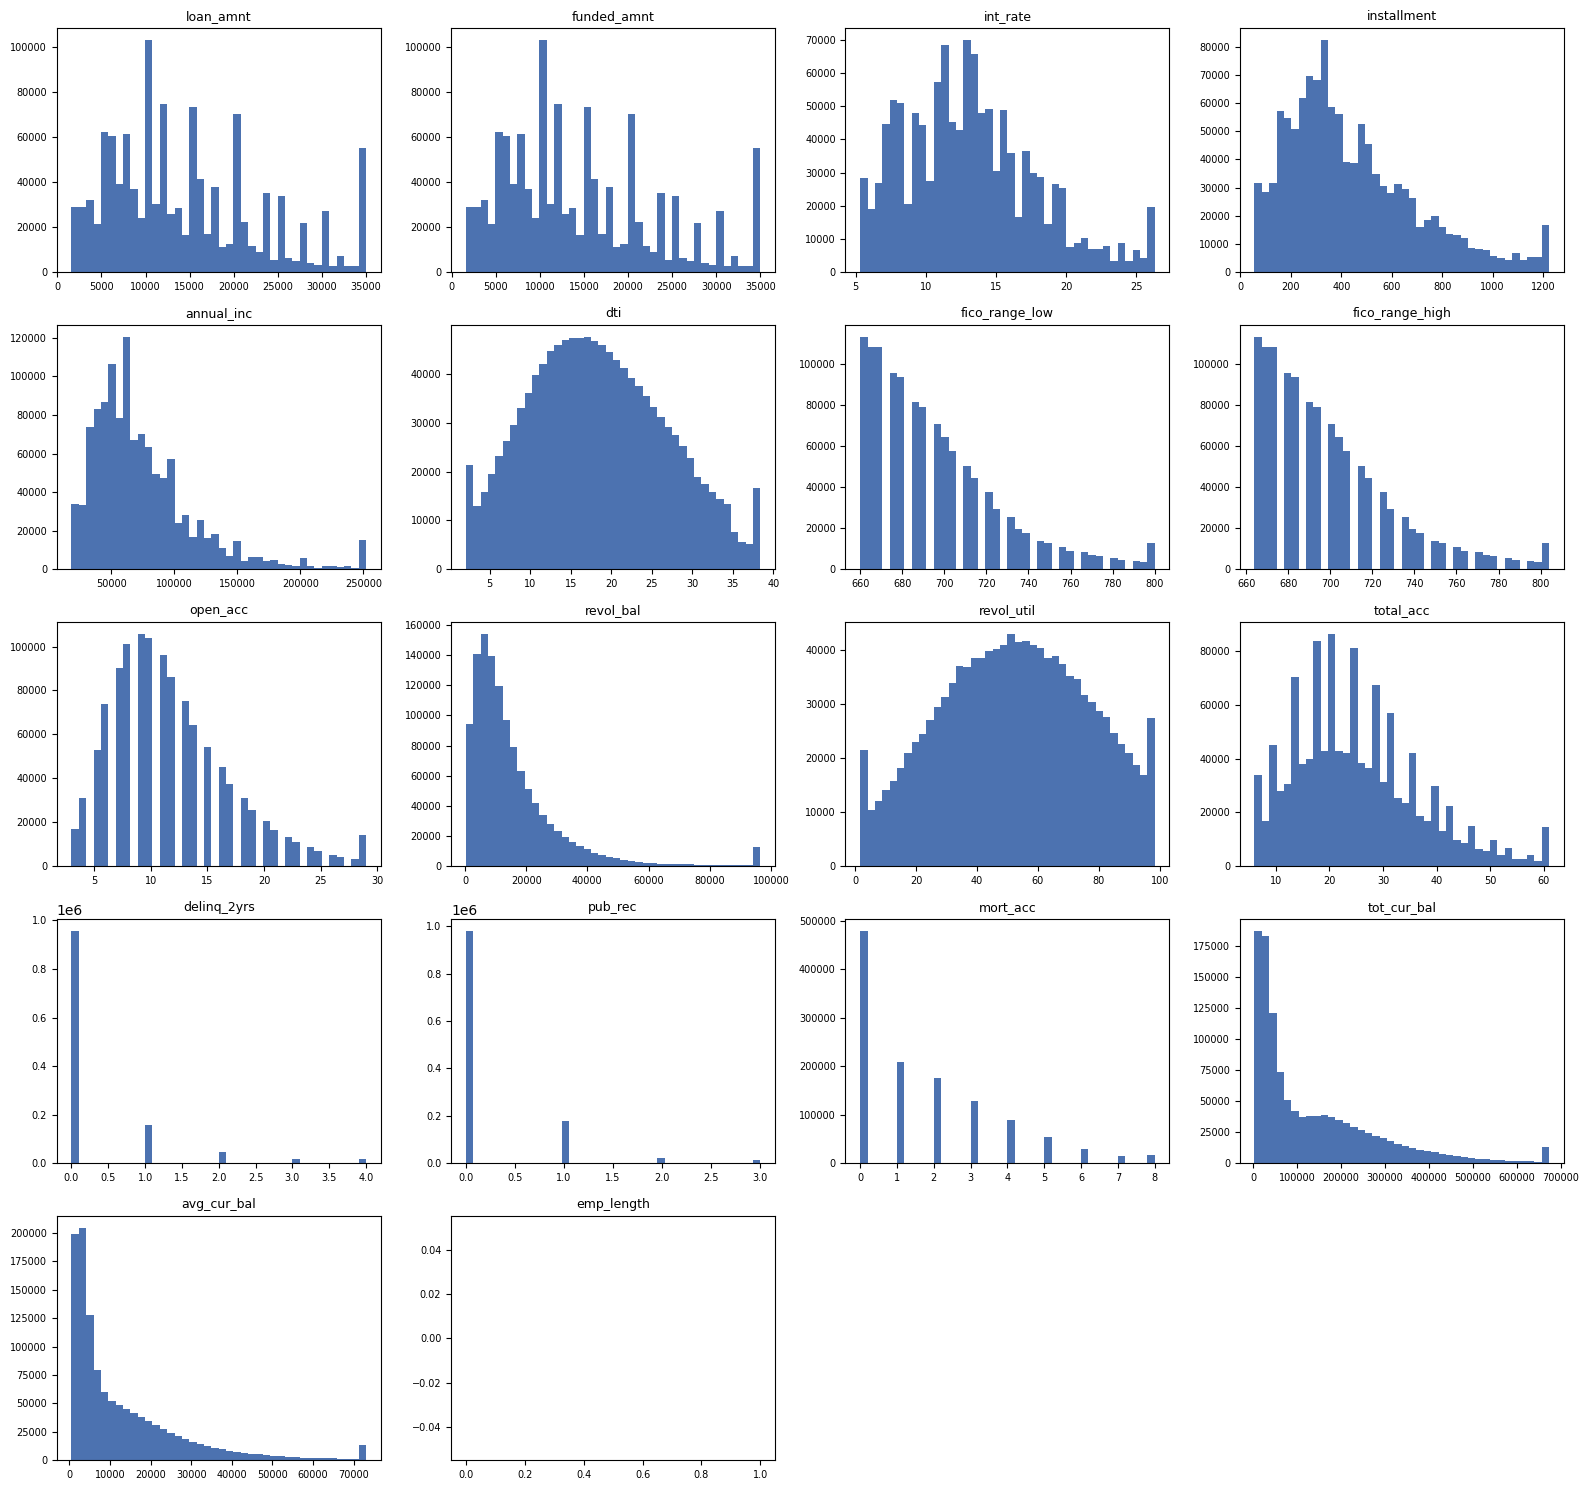

In [15]:
import matplotlib.pyplot as plt

n_cols = 4
n_rows_grid = -(-len(PD_NUMERIC_FIELDS) // n_cols)  # ceiling division
fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(n_cols * 4, n_rows_grid * 3))
axes = axes.flatten()

for ax, col in zip(axes, PD_NUMERIC_FIELDS):
    vals = con.sql(f'''
        SELECT TRY_CAST("{col}" AS DOUBLE) AS v FROM windowed
        WHERE TRY_CAST("{col}" AS DOUBLE) IS NOT NULL
    ''').df()["v"]
    # Clip to the 1st/99th percentile just for this plot, so a few extreme
    # values don't squash the whole histogram into one bar.
    lo, hi = vals.quantile([0.01, 0.99])
    ax.hist(vals.clip(lo, hi), bins=40, color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

# Turn off any unused subplot slots (the grid can have more cells than fields).
for ax in axes[len(PD_NUMERIC_FIELDS):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda03_numeric_small_multiples.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** histogram grid -> `eda03_numeric_small_multiples.png`.
Confirms 3.1's numbers visually -- `annual_inc` and `revol_bal` show a
long right tail, `fico_range_low/high` and `loan_amnt` look close to
well-behaved/bell-shaped.
**Next:** 3.3 sweeps the same fields for outliers by two methods.


### 3.3 Outlier detection: IQR and z-score sweep

**Why:** 3.1's stats show skew and range, not how many rows sit outside a
normal-looking band. IQR and z-score can disagree in informative ways: IQR
reacts badly to sparse count fields (mostly 0s); z-score reacts badly to a
genuinely heavy tail (extreme values inflate its own standard deviation).

**How:** for every field in `PD_NUMERIC_FIELDS`, count rows outside
`[Q1 - 1.5*IQR, Q3 + 1.5*IQR]`, and separately >3 standard deviations from
the mean.

**Answers:** which fields carry the heaviest tails, and where do the two
methods disagree?


In [16]:
n_rows_windowed = con.sql("SELECT count(*) FROM windowed").fetchone()[0]

iqr_rows = []
zscore_rows = []
skipped_fields = []
for col in PD_NUMERIC_FIELDS:
    p25, p75 = con.sql(f'''
        SELECT quantile_cont(TRY_CAST("{col}" AS DOUBLE), 0.25),
               quantile_cont(TRY_CAST("{col}" AS DOUBLE), 0.75)
        FROM windowed
    ''').fetchone()

    if p25 is None or p75 is None:
        # Every value fails TRY_CAST here (emp_length is text like
        # "10+ years" -- see 3.1's note on its near-zero cast rate) --
        # nothing to build a fence from. Skip it, don't crash.
        skipped_fields.append(col)
        continue

    iqr = p75 - p25
    lower_fence = p25 - 1.5 * iqr
    upper_fence = p75 + 1.5 * iqr
    n_iqr_outliers = con.sql(f'''
        SELECT count(*) FROM windowed
        WHERE TRY_CAST("{col}" AS DOUBLE) < {lower_fence} OR TRY_CAST("{col}" AS DOUBLE) > {upper_fence}
    ''').fetchone()[0]
    iqr_rows.append({
        "column": col, "lower_fence": lower_fence, "upper_fence": upper_fence,
        "n_outliers_iqr": n_iqr_outliers, "pct_outliers_iqr": 100 * n_iqr_outliers / n_rows_windowed,
    })

    n_z_outliers = con.sql(f'''
        WITH v AS (
            SELECT TRY_CAST("{col}" AS DOUBLE) AS x FROM windowed
            WHERE TRY_CAST("{col}" AS DOUBLE) IS NOT NULL
        ), m AS (SELECT avg(x) AS mu, stddev(x) AS sigma FROM v)
        SELECT count(*) FROM v, m WHERE abs(x - mu) > 3 * sigma
    ''').fetchone()[0]
    zscore_rows.append({
        "column": col, "n_outliers_zscore": n_z_outliers,
        "pct_outliers_zscore": 100 * n_z_outliers / n_rows_windowed,
    })

if skipped_fields:
    print(f"Skipped (cast rate too low to fence): {skipped_fields}")

outlier_df = pd.DataFrame(iqr_rows).merge(pd.DataFrame(zscore_rows), on="column")
outlier_df = outlier_df.sort_values("pct_outliers_iqr", ascending=False)
print(outlier_df.round(3).to_string(index=False))

outlier_df.to_csv(f"{ASSETS_TABLES}/eda03_outlier_detection.csv", index=False)


Skipped (cast rate too low to fence): ['emp_length']
         column  lower_fence  upper_fence  n_outliers_iqr  pct_outliers_iqr  n_outliers_zscore  pct_outliers_zscore
    delinq_2yrs        0.000        0.000          239211            20.003              17217                1.440
        pub_rec        0.000        0.000          215974            18.060              12531                1.048
      revol_bal   -14749.000    40771.000           71116             5.947              15086                1.261
    avg_cur_bal   -20142.500    41861.500           63209             5.286              20469                1.712
     annual_inc   -21500.000   158500.000           58326             4.877               8920                0.746
       open_acc       -1.000       23.000           43065             3.601              14163                1.184
    tot_cur_bal  -241011.750   480566.250           41489             3.469              17472                1.461
fico_range_high    

**Result:** IQR flags `delinq_2yrs` (20.0%) and `pub_rec` (18.1%)
hardest -- both degenerate cases (median = Q1 = Q3 = 0, so anything
nonzero counts as an outlier), not genuinely outlier-heavy. z-score tells
a calmer story for the same two fields (1.4% and 1.0%). `revol_bal` and
`avg_cur_bal` are flagged by both methods at a similar rate (~5-6%).
`emp_length` skipped -- its cast rate is too low to build a fence from
(see 3.1). Table -> `eda03_outlier_detection.csv`.
**Next:** 3.4 checks for values that are logically impossible -- something
neither statistical method catches.


### 3.4 Plausibility checks

**Why:** IQR/z-score catch statistically unusual values, not logically
impossible ones. A negative `dti` or `revol_util` over 100% might not be a
statistical outlier at all.

**How:** count rows breaking each explicit rule: `dti < 0`,
`annual_inc = 0`, `revol_util` outside 0-100, `fico_range_low` outside
300-850, `loan_amnt <= 0`.

**Answers:** how many rows break each rule, and which look like genuine
data errors vs. legitimate edge cases?


In [17]:
# Sanity-check rules: values that are technically present but don't make
# real-world sense (e.g. a negative debt-to-income ratio).
plausibility_rules = {
    "dti < 0": 'TRY_CAST("dti" AS DOUBLE) < 0',
    "annual_inc = 0": 'TRY_CAST("annual_inc" AS DOUBLE) = 0',
    "revol_util < 0": 'TRY_CAST("revol_util" AS DOUBLE) < 0',
    "revol_util > 100": 'TRY_CAST("revol_util" AS DOUBLE) > 100',
    "fico_range_low outside [300, 850]": 'TRY_CAST("fico_range_low" AS DOUBLE) NOT BETWEEN 300 AND 850',
    "loan_amnt <= 0": 'TRY_CAST("loan_amnt" AS DOUBLE) <= 0',
}

plausibility_rows = []
for label, condition in plausibility_rules.items():
    n_violations = con.sql(f"SELECT count(*) FROM windowed WHERE {condition}").fetchone()[0]
    plausibility_rows.append({"rule": label, "n_violations": n_violations})

plausibility_df = pd.DataFrame(plausibility_rows)
print(plausibility_df.to_string(index=False))

plausibility_df.to_csv(f"{ASSETS_TABLES}/eda03_plausibility_checks.csv", index=False)


                             rule  n_violations
                          dti < 0             2
                   annual_inc = 0           213
                   revol_util < 0             0
                 revol_util > 100          4571
fico_range_low outside [300, 850]             0
                   loan_amnt <= 0             0


**Result:** `revol_util` is the one real problem: **4,571 loans (0.4%)**
show utilization over 100% -- plausible for real accounts but worth a
documented cap. `annual_inc = 0` for 213 loans. `dti < 0` for just 2 loans.
Every other rule: 0 violations. Table -> `eda03_plausibility_checks.csv`.
**Next:** 3.5 moves to the PD-candidate categorical fields.


### 3.5 PD-candidate categorical distributions

**Why:** category frequency and cardinality decide which categorical
fields are usable directly vs. need grouping first.

**How:** Lending Club's data dictionary identifies these as PD-candidate
categorical fields: `grade`, `sub_grade`, `term`, `purpose`,
`home_ownership`, `verification_status`, `application_type`,
`initial_list_status`, `addr_state`. Pull value counts + share.

**Answers:** what are the category frequencies for each candidate
categorical field?


In [18]:
# Hand-picked categorical PD candidates.
PD_CATEGORICAL_FIELDS = [
    "grade", "sub_grade", "term", "purpose", "home_ownership",
    "verification_status", "application_type", "initial_list_status", "addr_state",
]
PD_CATEGORICAL_FIELDS = [c for c in PD_CATEGORICAL_FIELDS if c in ALL_COLUMNS]
print("PD categorical fields present:", PD_CATEGORICAL_FIELDS)

cat_frames = []
for col in PD_CATEGORICAL_FIELDS:
    vc = con.sql(f'''
        SELECT "{col}" AS category, count(*) AS n
        FROM windowed
        GROUP BY "{col}"
        ORDER BY n DESC
    ''').df()
    vc["field"] = col
    vc["share"] = round(vc["n"] / vc["n"].sum(), 4)
    cat_frames.append(vc)
    print(f"\n--- {col} ({len(vc)} categories) ---")
    print(vc.head(10).to_string())

pd_categorical_df = pd.concat(cat_frames, ignore_index=True)
pd_categorical_df.to_csv(f"{ASSETS_TABLES}/eda03_pd_categorical_distributions.csv", index=False)


PD categorical fields present: ['grade', 'sub_grade', 'term', 'purpose', 'home_ownership', 'verification_status', 'application_type', 'initial_list_status', 'addr_state']

--- grade (7 categories) ---
  category       n  field   share
0        B  346973  grade  0.2901
1        C  346953  grade  0.2901
2        A  201289  grade  0.1683
3        D  178643  grade  0.1494
4        E   84581  grade  0.0707
5        F   29030  grade  0.0243
6        G    8410  grade  0.0070

--- sub_grade (35 categories) ---
  category      n      field   share
0       C1  76696  sub_grade  0.0641
1       B4  73619  sub_grade  0.0616
2       B5  72984  sub_grade  0.0610
3       B3  71011  sub_grade  0.0594
4       C2  70960  sub_grade  0.0593
5       C3  68769  sub_grade  0.0575
6       C4  68410  sub_grade  0.0572
7       B2  65667  sub_grade  0.0549
8       B1  63692  sub_grade  0.0533
9       C5  62118  sub_grade  0.0519

--- term (2 categories) ---
     category       n field   share
0   36 months  90693

**Result:** `grade` is fairly even (B 29.0%, C 29.0%, A 16.8%, D 14.9%,
then a long tail down to G at 0.7%). `purpose` is dominated by
`debt_consolidation` (58.7%) and `credit_card` (22.4%). `home_ownership`:
mortgage 49.7%, rent 39.4%. `addr_state`: California alone is 14.4% of all
loans. Full tables -> `eda03_pd_categorical_distributions.csv`.
**Next:** 3.6 shows the same fields visually.


### 3.6 Visual check: PD-candidate categorical distributions

**Why:** 3.5's tables list top categories; a bar chart makes the shape --
one dominant category vs. a long thin tail -- visible at a glance.

**How:** bar chart of the top 10 categories per field in `PD_CATEGORICAL_FIELDS`.

**Answers:** what does each field's category distribution actually look
like?


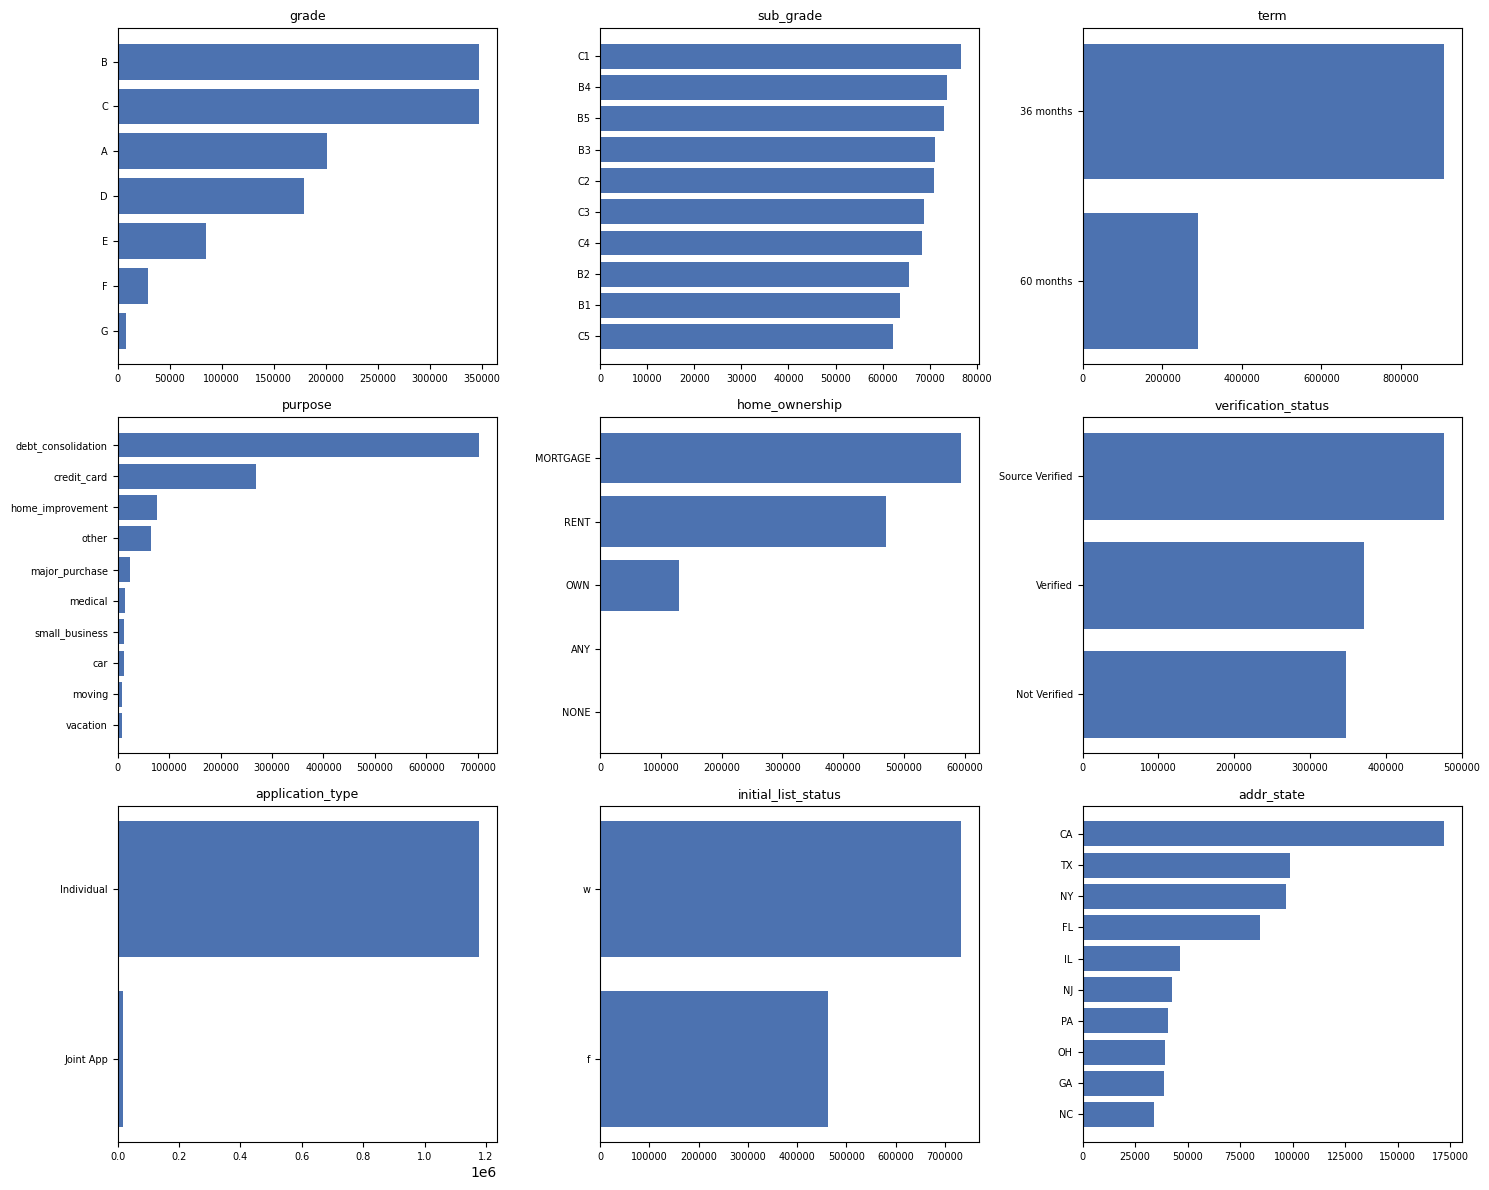

In [19]:
import matplotlib.pyplot as plt

n_cols = 3
n_rows_grid = -(-len(PD_CATEGORICAL_FIELDS) // n_cols)
fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(n_cols * 5, n_rows_grid * 4))
axes = axes.flatten()

for ax, col in zip(axes, PD_CATEGORICAL_FIELDS):
    # Top 10 categories only -- keeps every subplot readable even for
    # high-cardinality fields.
    vc = con.sql(f'''
        SELECT COALESCE("{col}", '(missing)') AS category, count(*) AS n
        FROM windowed GROUP BY 1 ORDER BY n DESC LIMIT 10
    ''').df()
    ax.barh(vc["category"][::-1], vc["n"][::-1], color="#4C72B0")
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(PD_CATEGORICAL_FIELDS):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda03_categorical_small_multiples.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** bar-chart grid -> `eda03_categorical_small_multiples.png`,
visual confirmation of 3.5's shares.
**Next:** 3.7 moves to the LGD-relevant recovery fields, on defaulted
loans only.


### 3.7 LGD-field distributions on the defaulted subset

**Why:** recovery/payment fields only mean something on loans that
defaulted -- profiling the whole population would dilute the picture.

**How:** the same recovery/payment fields from 1.5 (`total_pymnt`,
`total_pymnt_inv`, `total_rec_prncp`, `total_rec_int`,
`total_rec_late_fee`, `recoveries`, `collection_recovery_fee`,
`last_pymnt_amnt`, `out_prncp`, `out_prncp_inv`), minus the two date
fields. Filter to `is_bad = 1`, profile each.

**Answers:** what does the recovery-related data look like specifically
for loans that defaulted?


In [20]:
# LGD = Loss Given Default -- these fields describe what happens to payments
# and recoveries *after* a loan defaults, so they only make sense for bad loans.
LGD_FIELDS = [
    "total_pymnt", "total_pymnt_inv", "total_rec_prncp", "total_rec_int",
    "total_rec_late_fee", "recoveries", "collection_recovery_fee",
    "last_pymnt_amnt", "out_prncp", "out_prncp_inv",
]
LGD_FIELDS = [c for c in LGD_FIELDS if c in ALL_COLUMNS]
print("LGD fields present:", LGD_FIELDS)

lgd_rows = []
for col in LGD_FIELDS:
    r = con.sql(f'''
        SELECT
            count("{col}") AS n_non_null,
            avg(TRY_CAST("{col}" AS DOUBLE)) AS mean,
            min(TRY_CAST("{col}" AS DOUBLE)) AS min,
            max(TRY_CAST("{col}" AS DOUBLE)) AS max,
            sum(CASE WHEN TRY_CAST("{col}" AS DOUBLE) = 0 THEN 1 ELSE 0 END) AS n_zero
        FROM windowed
        WHERE is_bad = 1
    ''').fetchone()
    n_non_null, mean, mn, mx, n_zero = r
    lgd_rows.append({
        "column": col,
        "n_non_null": n_non_null,
        "mean": mean,
        "min": mn,
        "max": mx,
        "zero_share": round(n_zero / n_non_null, 4) if n_non_null else None,
    })

lgd_dist_df = pd.DataFrame(lgd_rows)
print(lgd_dist_df.to_string())

lgd_dist_df.to_csv(f"{ASSETS_TABLES}/eda03_lgd_field_distributions.csv", index=False)


LGD fields present: ['total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_amnt', 'out_prncp', 'out_prncp_inv']
                    column  n_non_null         mean           min           max  zero_share
0              total_pymnt      245411  8481.742399  0.000000e+00  61947.529797      0.0019
1          total_pymnt_inv      245411  8478.121460  0.000000e+00  61947.530000      0.0019
2          total_rec_prncp      245411  4479.071259  0.000000e+00  39989.790000      0.0072
3            total_rec_int      245411  2746.348829  0.000000e+00  26822.380000      0.0068
4       total_rec_late_fee      245411     4.755783 -5.100000e-09    874.170000      0.8646
5               recoveries      245411  1251.566527  0.000000e+00  39859.550000      0.3137
6  collection_recovery_fee      245411   211.739046  0.000000e+00   7174.719000      0.3312
7          last_pymnt_amnt      245411   474.962990  0.000000

**Result:** on the 245,411 defaulted loans, mean `total_pymnt` recovered
is **$8,482** against principal + interest owed, with `recoveries`
(post-charge-off collections) averaging $1,252 but **zero for 31.4%** of
defaults. `out_prncp` is ~0 for 99.99% of these loans (already closed
out). Table -> `eda03_lgd_field_distributions.csv`.
**Next:** 3.8 profiles the EAD-relevant loan-term/balance fields.


### 3.8 EAD-field distributions (loan terms & balances)

**Why:** the future EAD notebook needs the shape of the fields it will
build an amortization curve and observed-exposure path from -- both on the
full population and the defaulted subset.

**How:** Lending Club's data dictionary identifies `funded_amnt`,
`installment`, `int_rate`, `out_prncp`, `out_prncp_inv`, `total_rec_prncp`,
`total_pymnt`. `term` is categorical, checked separately. Describe twice:
full population, then defaulted only.

**Answers:** what do the balance/term fields look like, on the full
population and the defaulted subset?


In [21]:
# EAD = Exposure at Default -- these fields describe how much is actually at
# risk at the moment a loan defaults (funded amount, remaining principal, etc.).
EAD_FIELDS = [
    "funded_amnt", "installment", "int_rate",
    "out_prncp", "out_prncp_inv", "total_rec_prncp", "total_pymnt",
]
EAD_FIELDS = [c for c in EAD_FIELDS if c in ALL_COLUMNS]
print("EAD fields present:", EAD_FIELDS)

cols_sql = ", ".join(f'TRY_CAST("{c}" AS DOUBLE) AS "{c}"' for c in EAD_FIELDS)

# Compare the full population against just the defaulted loans, side by side.
full_desc = con.sql(f"SELECT {cols_sql} FROM windowed").df().describe().T
full_desc["population"] = "full"

bad_desc = con.sql(f"SELECT {cols_sql} FROM windowed WHERE is_bad = 1").df().describe().T
bad_desc["population"] = "defaulted"

ead_dist_df = pd.concat([full_desc, bad_desc])
print(ead_dist_df.to_string())

print("\n'term' value counts (full population):")
print(con.sql('SELECT "term", count(*) AS n FROM windowed GROUP BY "term"').df().to_string())

ead_dist_df.to_csv(f"{ASSETS_TABLES}/eda03_ead_field_distributions.csv")


EAD fields present: ['funded_amnt', 'installment', 'int_rate', 'out_prncp', 'out_prncp_inv', 'total_rec_prncp', 'total_pymnt']


                     count          mean           std      min          25%           50%           75%           max population
funded_amnt      1195879.0  14547.092139   8687.454241  1000.00  8000.000000  12000.000000  20000.000000  40000.000000       full
installment      1195879.0    442.271769    261.313351     4.93   252.640000    378.070000    586.240000   1719.830000       full
int_rate         1195879.0     13.253296      4.772168     5.32     9.750000     12.740000     15.990000     30.990000       full
out_prncp        1195879.0      0.251690     63.358096     0.00     0.000000      0.000000      0.000000  28222.010000       full
out_prncp_inv    1195879.0      0.251690     63.358096     0.00     0.000000      0.000000      0.000000  28222.010000       full
total_rec_prncp  1195879.0  12260.692921   8861.596645     0.00  5107.665000  10000.000000  17600.000000  40000.000000       full
total_pymnt      1195879.0  14970.189105  10336.987222     0.00  6978.557285  12277.200341

**Result:** defaulted loans were funded slightly larger on average
($15,621 vs $14,547 for the full population) and carry a higher rate
(15.7% vs 13.3%) -- consistent with riskier loans being priced and sized
differently at origination. Term mix: 75.8% are 36-month loans, 24.2% are
60-month. Table -> `eda03_ead_field_distributions.csv`.
**Next:** Section 03 closes below; Section 04 checks strength,
redundancy, and collinearity across the PD candidate set.


## Section 03 -- Output Interpretation & Governance Impact

Which PD-candidate fields need a transform (3.1-3.4 feed Section 09
directly, and 3.3/3.4 flag which rows are outliers/implausible before any
capping decision), what every candidate field looks like visually rather
than just as a stats table (3.2, 3.6), the LGD-relevant recovery-field
shape on the actual defaulted population (3.7 -- the first real look at
what a future LGD notebook works with), and the EAD-relevant field shape
on both populations (3.8).


# Section 04 -- Bivariate & Multivariate Collinearity Diagnostics

| Step | Answers |
|---|---|
| 4.1 | How strongly -- and how believably -- does each candidate relate to the target? |
| 4.2 | Does each PD-candidate numeric field have a clean, monotonic relationship with `is_bad`? |
| 4.3 | Which categories, within each PD-candidate categorical field, sit furthest from the overall bad rate? |
| 4.4 | Which numeric candidates are redundant with each other? |
| 4.5 | Is there a coarse and a fine version of the same rating signal, and which should modeling use? |
| 4.6 | Beyond grade/sub_grade, are any two categorical candidates close to redundant? |
| 4.7 | How well does the full candidate feature set predict `is_bad` in combination, and is that AUC leakage-suspicious? |
| 4.8 | Do the univariate and multivariate views agree on direction for every numeric candidate? |


### 4.1 Predictor-strength screen

**Why:** not every candidate field is useful, and some that look useful
only are because they leak the outcome. IV gives one comparable strength
score; a suspiciously high one is itself worth checking back against 2.2.

**How:** compute IV for every PD-candidate field from 3.1/3.5 -- numeric
binned into quantiles, categorical used as-is -- against `is_bad`.

**Answers:** how strongly -- and how believably -- does each candidate
relate to the target?


In [22]:
import numpy as np

# Information Value (IV) is a standard credit-risk score for "how much does
# this field, on its own, separate good loans from bad loans."
def compute_iv(df, feature, target, bins=10, is_numeric=True):
    d = df[[feature, target]].dropna()
    if is_numeric:
        d["bucket"] = pd.qcut(d[feature], q=bins, duplicates="drop")  # equal-sized bins
    else:
        d["bucket"] = d[feature]  # categories are already their own "buckets"
    grouped = d.groupby("bucket", observed=True)[target].agg(["count", "sum"])
    grouped.columns = ["n", "n_bad"]
    grouped["n_good"] = grouped["n"] - grouped["n_bad"]
    grouped["pct_good"] = grouped["n_good"] / grouped["n_good"].sum()
    grouped["pct_bad"] = grouped["n_bad"] / grouped["n_bad"].sum()
    grouped["woe"] = np.log((grouped["pct_good"] + 1e-6) / (grouped["pct_bad"] + 1e-6))
    grouped["iv"] = (grouped["pct_good"] - grouped["pct_bad"]) * grouped["woe"]
    return grouped["iv"].sum()

numeric_cols_sql = ", ".join(f'TRY_CAST("{c}" AS DOUBLE) AS "{c}"' for c in PD_NUMERIC_FIELDS)
categorical_cols_sql = ", ".join(f'"{c}"' for c in PD_CATEGORICAL_FIELDS)
target_df = con.sql(f"SELECT is_bad, {numeric_cols_sql}, {categorical_cols_sql} FROM windowed").df()

iv_rows = []
for col in PD_NUMERIC_FIELDS:
    iv_rows.append({"column": col, "type": "numeric", "iv": compute_iv(target_df, col, "is_bad", is_numeric=True)})
for col in PD_CATEGORICAL_FIELDS:
    iv_rows.append({"column": col, "type": "categorical", "iv": compute_iv(target_df, col, "is_bad", is_numeric=False)})

iv_df = pd.DataFrame(iv_rows).sort_values("iv", ascending=False)
print(iv_df.to_string())

iv_df.to_csv(f"{ASSETS_TABLES}/eda04_predictor_strength.csv", index=False)

print("\nRule-of-thumb IV bands: <0.02 useless, 0.02-0.1 weak, 0.1-0.3 medium,")
print("0.3-0.5 strong, >0.5 suspiciously strong -- worth a leakage re-check.")
print(iv_df.loc[iv_df["iv"] > 0.5])


                 column         type        iv
19            sub_grade  categorical  0.507925
18                grade  categorical  0.472565
2              int_rate      numeric  0.462660
20                 term  categorical  0.180901
7       fico_range_high      numeric  0.115930
6        fico_range_low      numeric  0.115930
5                   dti      numeric  0.074714
23  verification_status  categorical  0.054790
16          avg_cur_bal      numeric  0.050832
15          tot_cur_bal      numeric  0.039937
14             mort_acc      numeric  0.037647
0             loan_amnt      numeric  0.033197
1           funded_amnt      numeric  0.033197
22       home_ownership  categorical  0.032679
4            annual_inc      numeric  0.029879
3           installment      numeric  0.028489
10           revol_util      numeric  0.021571
21              purpose  categorical  0.018068
26           addr_state  categorical  0.017050
8              open_acc      numeric  0.005165
9            

**Result:** `sub_grade` (IV 0.51) and `grade` (IV 0.47) are flagged
**suspiciously strong** (>0.5 threshold) -- expected, since grade IS
Lending Club's own risk score, not leakage. `int_rate` (0.46) is strong
for the same reason (rate is set from grade). Genuinely useful,
non-circular signal: `term` (0.18), `fico_range_low/high` (0.12), `dti`
(0.07). `emp_length` scores 0.0 -- it's uncastable numerically (see 3.1).
Table -> `eda04_predictor_strength.csv`.
**Next:** 4.2 checks whether each numeric field's relationship with
`is_bad` is actually clean and monotonic, or lumpier than one IV number
can show.


### 4.2 Visual check: WOE curve per numeric field

**Why:** an IV score can't tell a clean monotonic relationship (higher
decile always = higher/lower risk) from a lumpy or non-monotonic one --
which needs different handling later (binning, a spline) than a single
linear term.

**How:** reuse `target_df` from 4.1. Bin each `PD_NUMERIC_FIELDS` field
into deciles the same way `compute_iv` does internally, but keep the
per-decile WOE to plot as a line.

**Answers:** does each field have a clean, monotonic relationship with
`is_bad`, or a lumpier one?


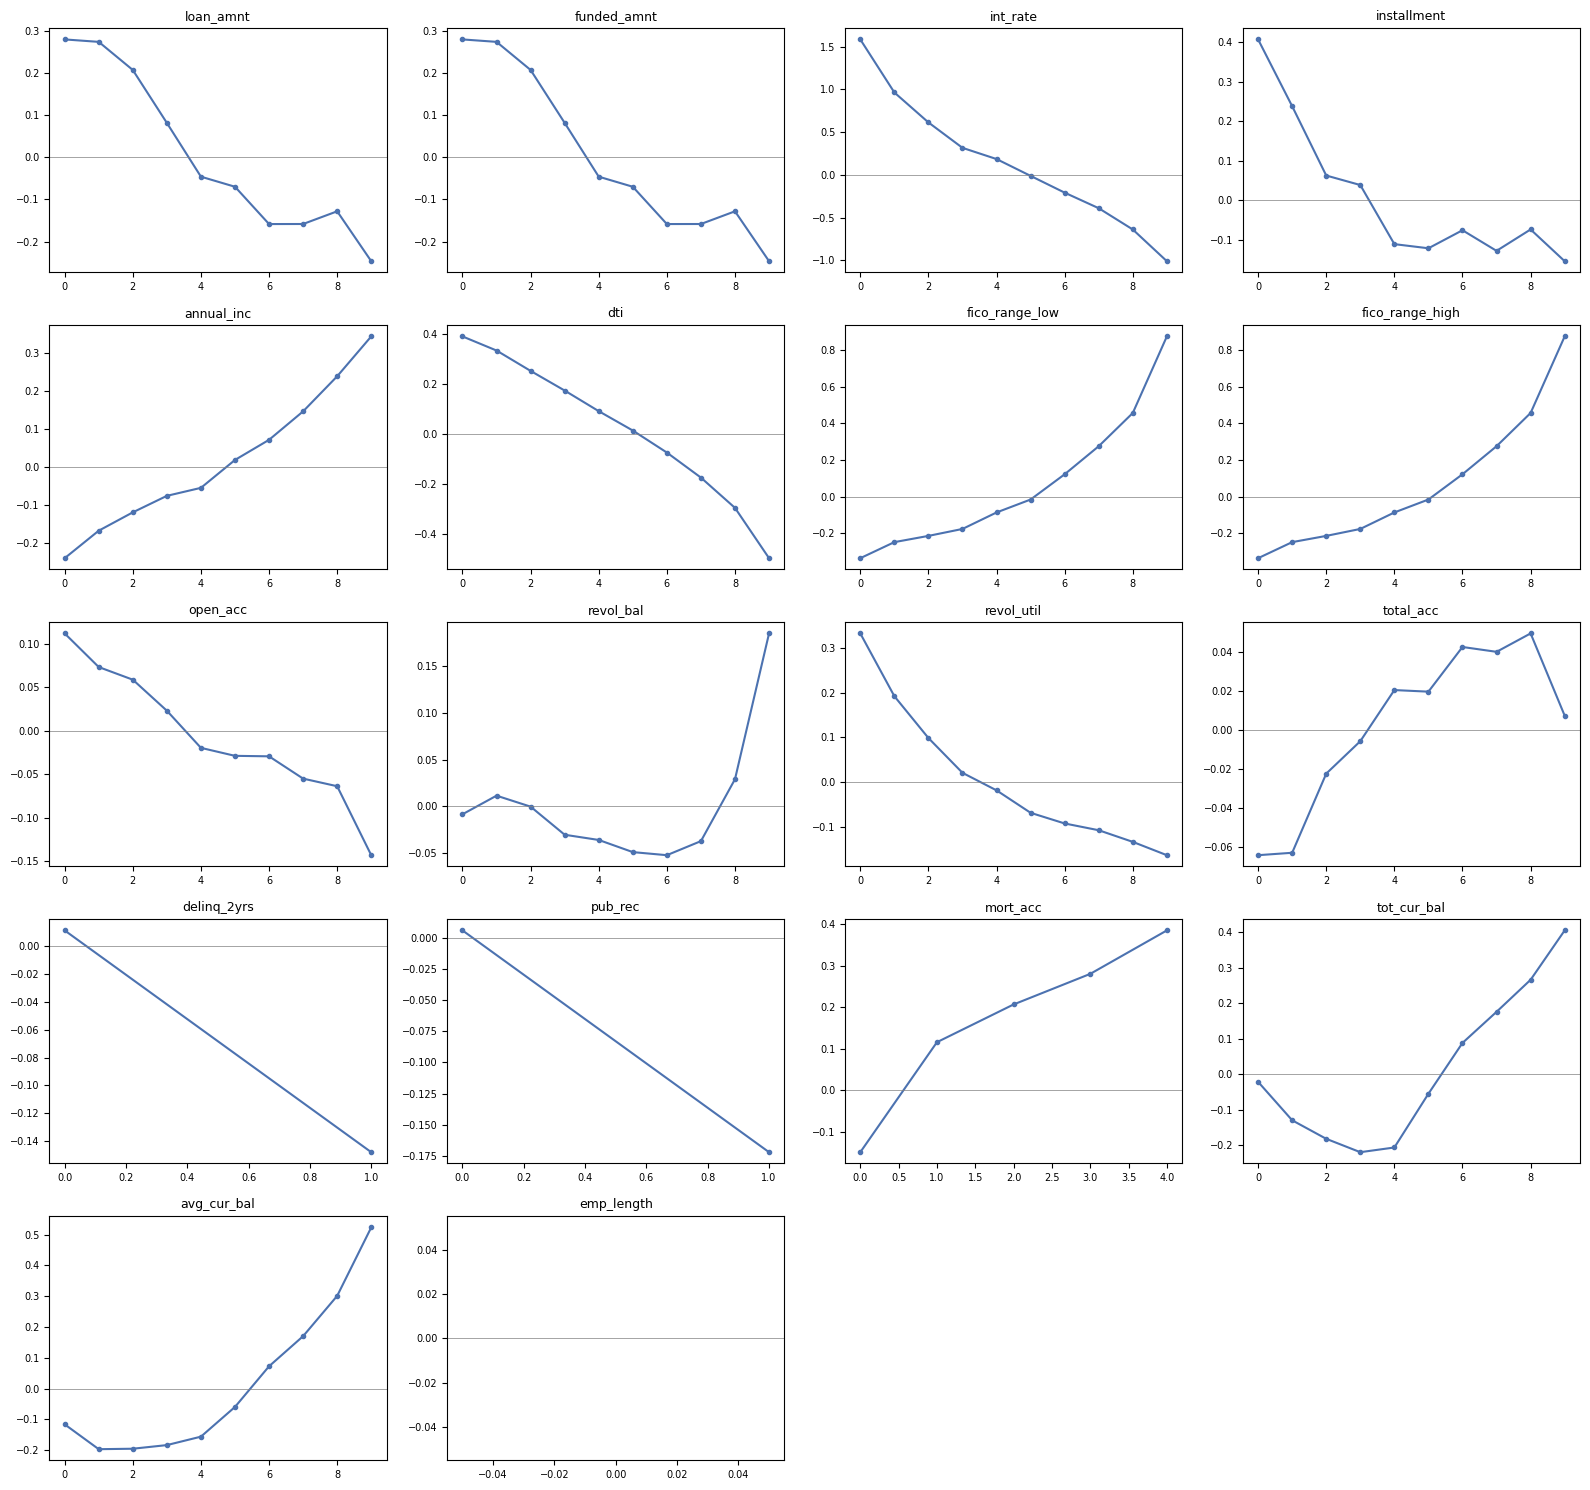

In [23]:
import matplotlib.pyplot as plt

# WOE (Weight of Evidence) per decile shows *how* a field's risk changes as
# the field's value increases, not just a single overall IV number.
def woe_by_decile(df, feature, target, bins=10):
    d = df[[feature, target]].dropna()
    d["bucket"] = pd.qcut(d[feature], q=bins, duplicates="drop")
    grouped = d.groupby("bucket", observed=True)[target].agg(["count", "sum"])
    grouped.columns = ["n", "n_bad"]
    grouped["n_good"] = grouped["n"] - grouped["n_bad"]
    grouped["pct_good"] = grouped["n_good"] / grouped["n_good"].sum()
    grouped["pct_bad"] = grouped["n_bad"] / grouped["n_bad"].sum()
    grouped["woe"] = np.log((grouped["pct_good"] + 1e-6) / (grouped["pct_bad"] + 1e-6))
    return grouped.reset_index(drop=True)


n_cols = 4
n_rows_grid = -(-len(PD_NUMERIC_FIELDS) // n_cols)
fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(n_cols * 4, n_rows_grid * 3))
axes = axes.flatten()

for ax, col in zip(axes, PD_NUMERIC_FIELDS):
    woe_df = woe_by_decile(target_df, col, "is_bad")
    ax.plot(range(len(woe_df)), woe_df["woe"], marker="o", markersize=3, color="#4C72B0")
    ax.axhline(0, color="grey", linewidth=0.5)  # 0 = this decile is average risk
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(PD_NUMERIC_FIELDS):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda04_woe_curve_small_multiples.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** WOE-curve grid -> `eda04_woe_curve_small_multiples.png`. A
steadily rising/falling line = clean and model-friendly; a zig-zag = a
candidate for explicit binning.
**Next:** 4.3 does the risk-view equivalent for the categorical fields.


### 4.3 Visual check: bad rate per categorical field

**Why:** 3.5 showed category *volume*; this is the risk view -- bad rate
by category against the overall baseline.

**How:** bar chart per `PD_CATEGORICAL_FIELDS` field, bad rate by category
(categories with <=200 rows dropped), with a line at the overall bad rate.

**Answers:** which categories sit furthest from the overall bad rate?


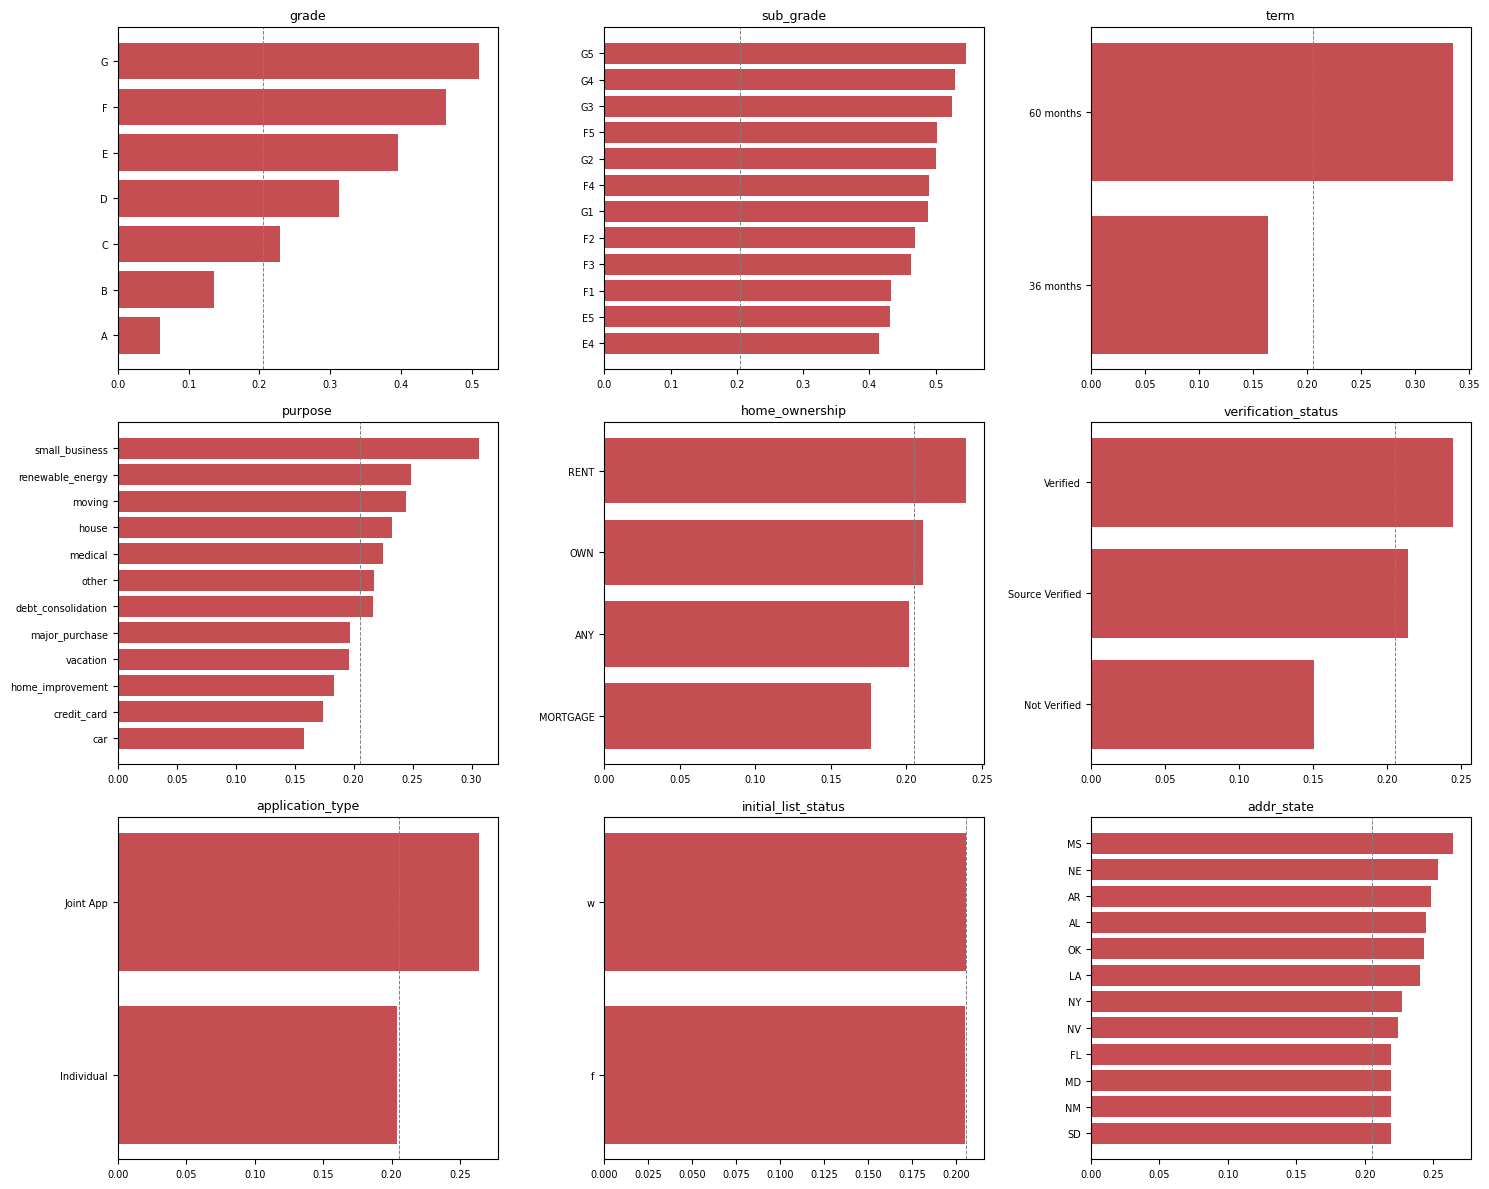

In [24]:
import matplotlib.pyplot as plt

overall_bad_rate = con.sql("SELECT avg(is_bad) FROM windowed").fetchone()[0]

n_cols = 3
n_rows_grid = -(-len(PD_CATEGORICAL_FIELDS) // n_cols)
fig, axes = plt.subplots(n_rows_grid, n_cols, figsize=(n_cols * 5, n_rows_grid * 4))
axes = axes.flatten()

for ax, col in zip(axes, PD_CATEGORICAL_FIELDS):
    # Only keep categories with a meaningful sample size (>200 loans) and show
    # the 12 riskiest -- avoids one rare category looking scarier than it is.
    vc = con.sql(f'''
        SELECT COALESCE("{col}", '(missing)') AS category, avg(is_bad) AS bad_rate, count(*) AS n
        FROM windowed GROUP BY 1 HAVING count(*) > 200 ORDER BY bad_rate DESC LIMIT 12
    ''').df()
    ax.barh(vc["category"][::-1], vc["bad_rate"][::-1], color="#C44E52")
    ax.axvline(overall_bad_rate, color="grey", linewidth=0.7, linestyle="--")  # population average, for reference
    ax.set_title(col, fontsize=9)
    ax.tick_params(labelsize=7)

for ax in axes[len(PD_CATEGORICAL_FIELDS):]:
    ax.axis("off")

plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda04_cat_bad_rate_small_multiples.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** bad-rate bar chart per field ->
`eda04_cat_bad_rate_small_multiples.png`. Same reading rule as 4.2: a
smooth step up/down across categories is clean signal; a spike on one
category alone is worth a closer look before trusting it.
**Next:** 4.4 checks redundancy between the numeric fields themselves.


### 4.4 Multicollinearity check

**Why:** two fields that move together don't each add new information --
better to know before feature selection than after.

**How:** reuse `target_df` from 4.1 -- no re-query -- pairwise correlation
across `PD_NUMERIC_FIELDS`, flag |r| > 0.7.

**Answers:** which numeric candidates are redundant with each other?


In [25]:
corr_matrix = target_df[PD_NUMERIC_FIELDS].corr()
print(corr_matrix.round(2).to_string())

# Flag any pair that's strongly correlated -- a sign the two fields carry
# largely the same information (redundant for modeling).
high_corr_pairs = []
for i, a in enumerate(PD_NUMERIC_FIELDS):
    for b in PD_NUMERIC_FIELDS[i + 1:]:
        r = corr_matrix.loc[a, b]
        if abs(r) > 0.7:
            high_corr_pairs.append({"field_a": a, "field_b": b, "correlation": r})

high_corr_df = pd.DataFrame(high_corr_pairs)
print("\nPairs with |correlation| > 0.7:")
print(high_corr_df.to_string() if len(high_corr_df) else "(none)")

corr_matrix.to_csv(f"{ASSETS_TABLES}/eda04_multicollinearity.csv")


                 loan_amnt  funded_amnt  int_rate  installment  annual_inc   dti  fico_range_low  fico_range_high  open_acc  revol_bal  revol_util  total_acc  delinq_2yrs  pub_rec  mort_acc  tot_cur_bal  avg_cur_bal  emp_length
loan_amnt             1.00         1.00      0.13         0.95        0.32  0.02            0.11             0.11      0.18       0.32        0.12       0.21        -0.01    -0.07      0.23         0.32         0.23         NaN
funded_amnt           1.00         1.00      0.13         0.95        0.32  0.02            0.11             0.11      0.18       0.32        0.12       0.21        -0.01    -0.07      0.23         0.32         0.23         NaN
int_rate              0.13         0.13      1.00         0.14       -0.08  0.15           -0.38            -0.38     -0.01      -0.04        0.22      -0.05         0.04     0.05     -0.08        -0.09        -0.09         NaN
installment           0.95         0.95      0.14         1.00        0.31  0.03        

**Result:** `fico_range_low` vs `fico_range_high` correlate at **1.00**
(they move in lockstep -- keep one), `loan_amnt` vs `installment` at 0.95,
`tot_cur_bal` vs `avg_cur_bal` at 0.84, `open_acc` vs `total_acc` at 0.70.
`emp_length` shows `NaN` throughout -- still uncastable. Table ->
`eda04_multicollinearity.csv`.
**Next:** 4.5 settles one specific redundancy question directly: grade
vs. sub_grade.


### 4.5 Rating-field redundancy check

**Why:** `grade`/`sub_grade` are a coarse and fine version of the same
rating. If `sub_grade` doesn't separate bad rates any better than `grade`
alone, it's redundant; if it does, it's real extra signal.

**How:** bad rate for every `sub_grade` within each `grade`; measure the
within-grade spread.

**Answers:** is there a coarse and fine version of the same rating signal,
and which should modeling use?


In [26]:
grade_bad_rate = con.sql('''
    SELECT grade, avg(is_bad) AS bad_rate, count(*) AS n
    FROM windowed
    GROUP BY grade
    ORDER BY grade
''').df()
print("Bad rate by grade:")
print(grade_bad_rate.to_string())

subgrade_bad_rate = con.sql('''
    SELECT grade, sub_grade, avg(is_bad) AS bad_rate, count(*) AS n
    FROM windowed
    GROUP BY grade, sub_grade
    ORDER BY grade, sub_grade
''').df()
print("\nBad rate by sub_grade, within grade:")
print(subgrade_bad_rate.to_string())

# If sub_grade barely spreads bad rate beyond what grade alone already shows,
# sub_grade is mostly redundant with grade.
spread = subgrade_bad_rate.groupby("grade")["bad_rate"].agg(["min", "max"])
spread["spread"] = spread["max"] - spread["min"]
print("\nWithin-grade bad-rate spread (max - min sub_grade bad rate, per grade):")
print(spread.to_string())

subgrade_bad_rate.to_csv(f"{ASSETS_TABLES}/eda04_rating_field_redundancy.csv", index=False)


Bad rate by grade:
  grade  bad_rate       n
0     A  0.060381  201289
1     B  0.135336  346973
2     C  0.228749  346953
3     D  0.311907  178643
4     E  0.395538   84581
5     F  0.463796   29030
6     G  0.510702    8410

Bad rate by sub_grade, within grade:
   grade sub_grade  bad_rate      n
0      A        A1  0.031926  38840
1      A        A2  0.046889  31649
2      A        A3  0.055014  31792
3      A        A4  0.068620  43136
4      A        A5  0.084497  55872
5      B        B1  0.104864  63692
6      B        B2  0.114258  65667
7      B        B3  0.131543  71011
8      B        B4  0.150084  73619
9      B        B5  0.169708  72984
10     C        C1  0.193126  76696
11     C        C2  0.212007  70960
12     C        C3  0.228940  68769
13     C        C4  0.253019  68410
14     C        C5  0.264915  62118
15     D        D1  0.284700  46614
16     D        D2  0.304603  39668
17     D        D3  0.313723  34795
18     D        D4  0.333153  31436
19     D       

**Result:** bad rate rises **monotonically** from grade A (6.0%) to G
(51.1%) -- an 8.5x spread. `sub_grade` adds real information within each
grade too: a 5-7 percentage-point spread from best to worst sub_grade
inside every letter grade (e.g. C1 19.3% vs C5 26.5%). `sub_grade` is not
redundant with `grade`. Table -> `eda04_rating_field_redundancy.csv`.
**Next:** 4.6 checks every other categorical pair the same way, not just
grade/sub_grade.


### 4.6 Categorical redundancy: Cramer's V heatmap

**Why:** 4.4 measured numeric redundancy with correlation; that doesn't
apply to unordered categories. 4.5 already tests grade/sub_grade
specifically -- this checks every other pair too.

**How:** full pairwise Cramer's V matrix across `PD_CATEGORICAL_FIELDS`
via `scipy.stats.chi2_contingency`.

**Answers:** beyond grade/sub_grade, are any two categorical candidates
close to redundant?


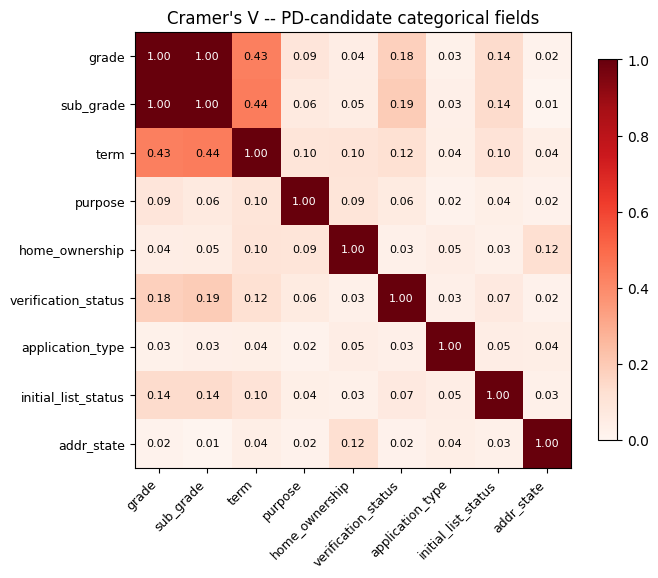

In [27]:
from scipy.stats import chi2_contingency

# Cramer's V is correlation's equivalent for two categorical fields --
# 0 = no association, 1 = perfectly linked.
cols = PD_CATEGORICAL_FIELDS
n = len(cols)
cramers_v_matrix = np.eye(n)  # diagonal = 1 (every field is perfectly "linked" with itself)

for i in range(n):
    for j in range(i + 1, n):
        ct = con.sql(f'''
            SELECT "{cols[i]}" AS a, "{cols[j]}" AS b, count(*) AS n
            FROM windowed GROUP BY 1, 2
        ''').df()
        pivot = ct.pivot(index="a", columns="b", values="n").fillna(0)
        chi2, p_value, dof, expected = chi2_contingency(pivot)
        n_obs = pivot.values.sum()
        r, k = pivot.shape
        # Bias-corrected Cramer's V formula -- raw phi2 tends to overstate
        # association for small samples/tables.
        phi2 = chi2 / n_obs
        phi2_corrected = max(0, phi2 - ((k - 1) * (r - 1)) / (n_obs - 1))
        r_corrected = r - ((r - 1) ** 2) / (n_obs - 1)
        k_corrected = k - ((k - 1) ** 2) / (n_obs - 1)
        denom = min(k_corrected - 1, r_corrected - 1)
        v = np.sqrt(phi2_corrected / denom) if denom > 0 else 0
        cramers_v_matrix[i, j] = cramers_v_matrix[j, i] = v

import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cramers_v_matrix, cmap="Reds", vmin=0, vmax=1)
ax.set_xticks(range(n)); ax.set_xticklabels(cols, rotation=45, ha="right", fontsize=9)
ax.set_yticks(range(n)); ax.set_yticklabels(cols, fontsize=9)
for i in range(n):
    for j in range(n):
        ax.text(j, i, f"{cramers_v_matrix[i, j]:.2f}", ha="center", va="center", fontsize=8,
                color="white" if cramers_v_matrix[i, j] > 0.5 else "black")
plt.colorbar(im, shrink=0.8)
plt.title("Cramer's V -- PD-candidate categorical fields")
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda04_cramers_v_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()

cramers_v_df = pd.DataFrame(cramers_v_matrix, index=cols, columns=cols)
cramers_v_df.to_csv(f"{ASSETS_TABLES}/eda04_cramers_v.csv")


**Result:** as expected, `grade` and `sub_grade` are near-identical
(Cramer's V ~ 1.00 -- sub_grade IS grade, subdivided). Everything
else is much weaker: `sub_grade`/`term` 0.44, `grade`/`term` 0.43, and
every other pair below 0.2 -- genuinely different information, not
restating each other. Matrix -> `eda04_cramers_v.csv`.
**Next:** 4.7 tests every candidate field together, in one model.


### 4.7 Baseline multivariate model: logistic regression

**Why:** 4.1-4.6 look at one or two fields at a time. One logistic
regression across every candidate field shows what still matters once
everything else is held constant, and how well the whole set predicts
`is_bad` together -- a very high AUC would itself be a second, independent
leakage check against 2.2.

**How:** numeric fields standardized (median-imputed first), categorical
one-hot encoded, 75/25 train/test split; report holdout AUC + top
coefficients.

**Answers:** how well does the full candidate feature set predict `is_bad`
in combination, and is that AUC leakage-suspicious?


In [28]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score
import gc

# This is a quick baseline sanity check, not the final model -- so we fit it
# on a random sample of loans instead of all 1M+. That keeps it fast while
# still giving a reliable AUC and coefficient signs. The real model gets
# built properly (with the full population) in the modeling phase later.
SAMPLE_SIZE = 200_000
model_df = target_df.sample(n=min(SAMPLE_SIZE, len(target_df)), random_state=42)
print(f"Baseline model uses a random sample of {len(model_df):,} loans "
      f"(out of {len(target_df):,} in the full PD population).")

# Build numeric + one-hot categorical feature tables separately. Keeping them
# separate (instead of merging everything into one giant table first) uses
# less memory.
X_numeric = model_df[PD_NUMERIC_FIELDS].apply(pd.to_numeric, errors="coerce")

# emp_length is stored as text ("10+ years", "< 1 year", ...) so it fails
# this cast almost entirely -- same issue flagged back in 3.1 and fixed in
# 3.3. Drop any numeric field that came out all-missing instead of handing
# sklearn a column of NaNs.
all_nan_numeric = [c for c in X_numeric.columns if X_numeric[c].isna().all()]
if all_nan_numeric:
    print(f"Dropping numeric fields that failed to cast entirely: {all_nan_numeric}")
    X_numeric = X_numeric.drop(columns=all_nan_numeric)
X_numeric = X_numeric.fillna(X_numeric.median())
numeric_feature_names = list(X_numeric.columns)

X_categorical = pd.get_dummies(model_df[PD_CATEGORICAL_FIELDS].astype(str), drop_first=True)
categorical_feature_names = list(X_categorical.columns)
y = model_df["is_bad"].astype(int)

# Split row positions once, then slice train/test directly out of the feature
# tables above -- we never build one "all rows, all columns" copy first.
train_idx, test_idx = train_test_split(
    np.arange(len(model_df)), test_size=0.25, random_state=42, stratify=y
)
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

scaler = StandardScaler()
X_train_numeric_scaled = scaler.fit_transform(X_numeric.iloc[train_idx])
X_test_numeric_scaled = scaler.transform(X_numeric.iloc[test_idx])

X_train_full = np.hstack(
    [X_train_numeric_scaled, X_categorical.iloc[train_idx].values]
).astype(np.float32)
X_test_full = np.hstack(
    [X_test_numeric_scaled, X_categorical.iloc[test_idx].values]
).astype(np.float32)

del X_numeric, X_categorical
gc.collect()

logistic_model = LogisticRegression(max_iter=1000)
logistic_model.fit(X_train_full, y_train)

holdout_auc = roc_auc_score(y_test, logistic_model.predict_proba(X_test_full)[:, 1])
print(f"Baseline logistic regression AUC (holdout): {holdout_auc:.3f}")
print("An AUC above roughly 0.85 here would be suspicious for an")
print("origination-time-only feature set -- worth a leakage re-check")
print("against 2.1 if it happens.")

logistic_coef_df = pd.DataFrame({
    "feature": numeric_feature_names + categorical_feature_names,
    "coefficient": logistic_model.coef_[0],
}).sort_values("coefficient", key=abs, ascending=False)

print("\nTop 15 coefficients by magnitude:")
print(logistic_coef_df.head(15).round(3).to_string(index=False))

logistic_coef_df.to_csv(f"{ASSETS_TABLES}/eda04_logistic_baseline_coefficients.csv", index=False)


Baseline model uses a random sample of 200,000 loans (out of 1,195,879 in the full PD population).
Dropping numeric fields that failed to cast entirely: ['emp_length']


Baseline logistic regression AUC (holdout): 0.717
An AUC above roughly 0.85 here would be suspicious for an
origination-time-only feature set -- worth a leakage re-check
against 2.1 if it happens.

Top 15 coefficients by magnitude:
                feature  coefficient
                grade_G        1.716
                grade_F        1.685
                grade_E        1.645
                grade_D        1.470
                grade_C        1.225
          addr_state_ME       -0.911
                grade_B        0.859
        term_ 60 months        0.735
        purpose_wedding       -0.735
home_ownership_MORTGAGE       -0.721
           sub_grade_A5        0.681
          addr_state_DC       -0.647
     home_ownership_OWN       -0.642
           sub_grade_G2        0.554
    home_ownership_RENT       -0.521


**Result:** baseline holdout **AUC = 0.717** on a 200,000-loan sample
(well below the ~0.85 leakage-suspicion line, as expected for
origination-time-only features). `emp_length` was dropped (uncastable).
Top drivers by coefficient size are almost all `grade`/`sub_grade`
dummies, as expected -- e.g. `grade_G` (+1.72), `grade_F` (+1.69), down to
`grade_B` (+0.86). Coefficients ->
`eda04_logistic_baseline_coefficients.csv`.
**Next:** 4.8 checks whether any field's multivariate direction disagrees
with its own univariate WOE direction from 4.2.


### 4.8 Univariate-vs-multivariate sign agreement check

**Why:** a feature's simple relationship with risk can flip once every
other feature is held constant -- usually because the univariate view was
partly riding on correlation with a stronger field. 4.1-4.6 would never
catch that on their own.

**How:** for every `PD_NUMERIC_FIELDS` field, compare the multivariate
coefficient sign (4.7) against the univariate WOE slope direction (4.2).

**Answers:** do the univariate and multivariate views agree on direction,
and if not, which fields disagree?


In [29]:
sign_rows = []
skipped_sign_fields = []
for col in PD_NUMERIC_FIELDS:
    woe_df = woe_by_decile(target_df, col, "is_bad")
    if len(woe_df) == 0:
        # Same emp_length text-cast issue as before -- no usable deciles
        # means nothing to compare a direction against. Skip it.
        skipped_sign_fields.append(col)
        continue
    uni_slope = np.polyfit(range(len(woe_df)), woe_df["woe"], 1)[0]
    univariate_direction = "protective" if uni_slope > 0 else "risk-raising"

    coef_row = logistic_coef_df[logistic_coef_df["feature"] == col]
    if len(coef_row) == 0:
        continue
    coef_value = coef_row.iloc[0]["coefficient"]
    multivariate_direction = "risk-raising" if coef_value > 0 else "protective"

    sign_rows.append({
        "column": col,
        "univariate_woe_slope": uni_slope,
        "univariate_direction": univariate_direction,
        "multivariate_coefficient": coef_value,
        "multivariate_direction": multivariate_direction,
        "agree": univariate_direction == multivariate_direction,
    })

if skipped_sign_fields:
    print(f"Skipped (no usable deciles to compare): {skipped_sign_fields}")

sign_agreement_df = pd.DataFrame(sign_rows)
print(sign_agreement_df.round(4).to_string(index=False))

n_agree = sign_agreement_df["agree"].sum()
print(f"\n{n_agree} of {len(sign_agreement_df)} PD-numeric fields agree in direction.")

disagreements = sign_agreement_df[~sign_agreement_df["agree"]]
if len(disagreements):
    print("\nDisagreements (worth a closer look, not necessarily a bug):")
    print(disagreements.to_string(index=False))

sign_agreement_df.to_csv(f"{ASSETS_TABLES}/eda04_sign_agreement.csv", index=False)


Skipped (no usable deciles to compare): ['emp_length']
         column  univariate_woe_slope univariate_direction  multivariate_coefficient multivariate_direction  agree
      loan_amnt               -0.0615         risk-raising                   -0.1426             protective  False
    funded_amnt               -0.0615         risk-raising                   -0.1376             protective  False
       int_rate               -0.2506         risk-raising                   -0.0162             protective  False
    installment               -0.0517         risk-raising                    0.3643           risk-raising   True
     annual_inc                0.0601           protective                   -0.1020             protective   True
            dti               -0.0931         risk-raising                    0.1104           risk-raising   True
 fico_range_low                0.1166           protective                   -0.0810             protective   True
fico_range_high          

**Result:** **13 of 17** PD-numeric fields agree in direction. The 4
disagreements -- `loan_amnt`, `funded_amnt`, `int_rate`, `revol_util` --
all flip from risk-raising alone to protective once grade/sub_grade are
in the model. That's expected, not a bug: grade already prices in the
rate and loan size, so once grade is controlled for, a bit more
loan_amnt/rate within the same grade reads as protective (better-
qualified borrowers within a grade tend to get slightly larger/cheaper
loans). Table -> `eda04_sign_agreement.csv`.
**Next:** Section 04 closes below; Section 05 looks for cluster/anomaly
structure in the candidate features.


## Section 04 -- Output Interpretation & Governance Impact

Every PD-candidate field scored for strength (4.1) and shown visually,
numeric as a WOE curve and categorical as bad rate (4.2, 4.3); numeric
redundancy (4.4), the grade/sub_grade question settled directly (4.5), and
categorical redundancy beyond that pair (4.6); a baseline multivariate
model as a second independent leakage check (4.7); and whether every
field's univariate and multivariate risk direction agree (4.8). Section 05
turns to unsupervised structure -- clustering and anomaly detection -- as
candidate engineered features.


# Section 05 -- Pattern, Anomaly & Latent-Structure Discovery

**Section question:** do cluster- or anomaly-based groupings of loans show
materially different bad rates from each other -- structure the target
field alone wouldn't show us?

| # | Step |
|---|---|
| 5.1 | Build a scaled numeric feature matrix (same fields as Section 04) |
| 5.2 | KMeans clustering -- bad rate per cluster |
| 5.3 | Visual check: clusters on a 2-D PCA projection |
| 5.4 | Isolation Forest anomaly detection -- bad rate, anomaly vs. normal |


### 5.1 Clustering feature matrix

**Why:** clustering and anomaly detection both need one clean numeric
table -- no missing values, no text columns.

**How:** reuse the same PD-numeric fields and same cast/drop/fill logic as
4.7, then scale them (clustering distances are meaningless if one field is
measured in dollars and another in years). Sample 200,000 loans, same as
4.7, so this stays fast.

**Answers:** how many loans and fields go into the clustering / anomaly
steps below?


In [30]:
from sklearn.preprocessing import StandardScaler

# Same cast -> drop-all-NaN -> median-fill logic as 4.7's baseline model.
cluster_numeric = target_df[PD_NUMERIC_FIELDS].apply(pd.to_numeric, errors="coerce")
all_nan_cols = [c for c in cluster_numeric.columns if cluster_numeric[c].isna().all()]
if all_nan_cols:
    print(f"Dropping fields that failed to cast entirely: {all_nan_cols}")
    cluster_numeric = cluster_numeric.drop(columns=all_nan_cols)
cluster_numeric = cluster_numeric.fillna(cluster_numeric.median())

# Same 200,000-loan sample as 4.7 -- clustering all 1.2M rows isn't needed
# to see whether clusters differ in bad rate.
cluster_sample = cluster_numeric.sample(n=min(200_000, len(cluster_numeric)), random_state=42)
cluster_is_bad = target_df.loc[cluster_sample.index, "is_bad"]

scaler_5 = StandardScaler()
cluster_scaled = scaler_5.fit_transform(cluster_sample)
print(f"Clustering feature matrix: {cluster_scaled.shape[0]:,} loans x {cluster_scaled.shape[1]} fields")


Dropping fields that failed to cast entirely: ['emp_length']


Clustering feature matrix: 200,000 loans x 17 fields


**Result:** 200,000 loans x 17 fields (`emp_length` dropped -- uncastable,
same as 4.7).
**Next:** 5.2 runs KMeans on this matrix and checks each cluster's bad
rate.


### 5.2 KMeans clustering -- bad rate per cluster

**Why:** if loans naturally group into a handful of clusters with very
different bad rates, that grouping itself is a useful engineered feature
(and a sanity check that grade isn't the only thing driving risk).

**How:** KMeans with 4 clusters (a simple, interpretable starting point)
on the scaled matrix from 5.1, then group by cluster and look at bad rate.

**Answers:** do the 4 clusters have noticeably different bad rates, or
are they all close to the 20.5% population average?


In [31]:
from sklearn.cluster import KMeans

# 4 clusters is a simple starting point -- this step isn't trying to find the
# "true" number of clusters, just checking whether unsupervised groupings line
# up with risk at all.
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(cluster_scaled)

cluster_summary = pd.DataFrame({
    "cluster": cluster_labels,
    "is_bad": cluster_is_bad.values,
}).groupby("cluster")["is_bad"].agg(["count", "mean"]).rename(columns={"mean": "bad_rate"})
print(cluster_summary.round(4))

cluster_summary.to_csv(f"{ASSETS_TABLES}/eda05_cluster_summary.csv")


         count  bad_rate
cluster                 
0        34429    0.1081
1        99220    0.2192
2        20055    0.1274
3        46296    0.2823


**Result:** a real spread -- cluster bad rates range from **10.8%**
(cluster 0, 34,429 loans) up to **28.2%** (cluster 3, 46,296 loans),
against a 20.5% population average. Table -> `eda05_cluster_summary.csv`.
**Next:** 5.3 shows the same clusters visually on a 2-D projection.


### 5.3 Visual check: clusters on a 2-D PCA projection

**Why:** a bad-rate table tells us clusters differ, but not whether they
are cleanly separated groups or one blob KMeans arbitrarily cut into 4.

**How:** project the same scaled matrix down to its first 2 principal
components (the 2 directions that capture the most spread in the data)
and color each point by its cluster.

**Answers:** do the 4 clusters look like separate groups in this
2-D view, or heavily overlapping?


First 2 principal components explain 40.1% of the total spread.


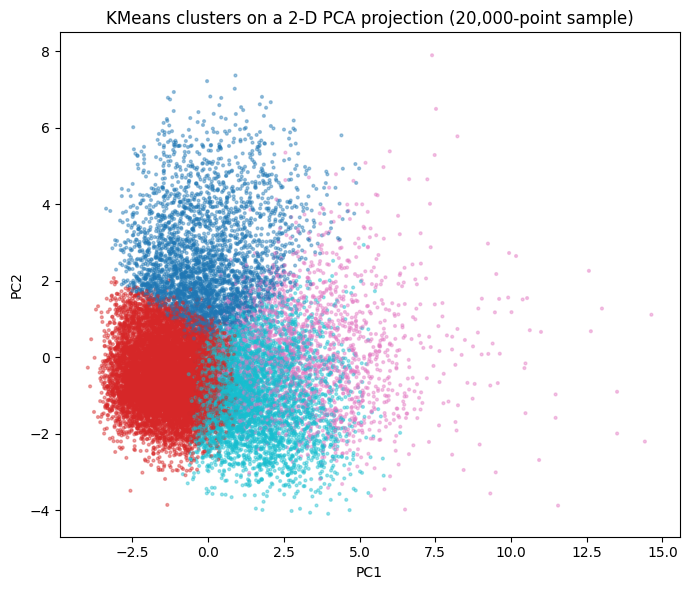

In [32]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2, random_state=42)
pca_coords = pca.fit_transform(cluster_scaled)
print(f"First 2 principal components explain {pca.explained_variance_ratio_.sum():.1%} of the total spread.")

# Plot a random subset of points (not all 200,000) -- this is just a
# visual check, and matplotlib renders a lot faster with fewer dots.
plot_idx = np.random.RandomState(42).choice(len(pca_coords), size=min(20_000, len(pca_coords)), replace=False)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(pca_coords[plot_idx, 0], pca_coords[plot_idx, 1], c=cluster_labels[plot_idx],
           cmap="tab10", s=4, alpha=0.4)
ax.set_xlabel("PC1"); ax.set_ylabel("PC2")
ax.set_title("KMeans clusters on a 2-D PCA projection (20,000-point sample)")
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda05_pca_projection.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** the first 2 principal components explain only **40.1%** of
the total spread -- a meaningful but partial view. The scatter
(`eda05_pca_projection.png`) shows overlapping, not sharply separated,
clouds -- consistent with 5.2's bad-rate spread being a soft split, not
distinct loan "types."
**Next:** 5.4 tries a different lens -- anomaly detection instead of
clustering.


### 5.4 Isolation Forest anomaly detection

**Why:** clustering groups the bulk of loans; anomaly detection instead
asks a narrower question -- are the small number of loans that look
statistically unusual also more likely to be bad?

**How:** Isolation Forest, flagging the most unusual 5% of loans in the
same scaled feature matrix, then compare bad rate between the flagged
("anomaly") and unflagged ("normal") groups.

**Answers:** is the anomaly group's bad rate meaningfully different from
the normal group's?


In [33]:
from sklearn.ensemble import IsolationForest

# contamination=0.05 tells the model to flag the most unusual 5% of loans as anomalies.
iso = IsolationForest(contamination=0.05, random_state=42, n_jobs=-1)
anomaly_flag = iso.fit_predict(cluster_scaled)  # -1 = anomaly, 1 = normal

anomaly_summary = pd.DataFrame({
    "is_anomaly": anomaly_flag == -1,
    "is_bad": cluster_is_bad.values,
}).groupby("is_anomaly")["is_bad"].agg(["count", "mean"]).rename(columns={"mean": "bad_rate"})
print(anomaly_summary.round(4))

anomaly_summary.to_csv(f"{ASSETS_TABLES}/eda05_anomaly_summary.csv")


             count  bad_rate
is_anomaly                  
False       190000    0.2072
True         10000    0.1732


**Result:** surprising -- the flagged 5% ("anomaly") group has a
**lower** bad rate (17.3%, 10,000 loans) than the normal group (20.7%,
190,000 loans) -> `eda05_anomaly_summary.csv`. Being statistically
unusual on these fields isn't the same as being risky here: an unusual
loan is just as likely to be an unusually strong applicant as a weak one.
**Next:** Section 05 closes below; Section 06 turns to time and geography.


## Section 05 -- Output Interpretation & Governance Impact

Two independent lenses on latent structure: KMeans clustering (5.1-5.3)
and Isolation Forest anomaly detection (5.4), both on the same scaled
PD-numeric feature matrix and the same 200,000-loan sample used in 4.7.
Whatever spread either method finds is a candidate engineered feature
(a cluster id, or an "is_anomaly" flag) for the cleaning/feature-prep
notebook to build -- not a replacement for the grade/sub_grade signal
Section 04 already established as dominant.

Section 06 moves from *what* structure exists to *when and where* it
shows up -- vintage and geography.


# Section 06 -- Temporal, Sequential & Spatial Analysis

**Section question:** does risk move across loan vintage (issue year) or
geography (state)?

| # | Step |
|---|---|
| 6.1 | Bad rate by issue year (vintage trend) |
| 6.2 | Grade mix by issue year -- has underwriting shifted? |
| 6.3 | Bad rate by state |


### 6.1 Bad rate by issue year

**Why:** a rising or falling bad rate across vintages would point to
either changing borrower quality or changing economic conditions -- either
way, something a model needs to know about.

**How:** pull the issue year out of `issue_d` (stored like `"Dec-2015"`)
and group bad rate by it. Note: `windowed` already only contains loans
with a known final outcome, so this isn't comparing "young, still-open"
loans to "old, resolved" ones -- but younger vintages in this window
still had less time to season before being excluded from `windowed`,
so read this as a directional trend, not a precise causal read.

**Answers:** does bad rate trend up, down, or stay flat across vintages?


   issue_year  bad_rate       n
0        2013  0.155960  134804
1        2014  0.184498  223103
2        2015  0.201850  375546
3        2016  0.232859  293105
4        2017  0.231330  169321


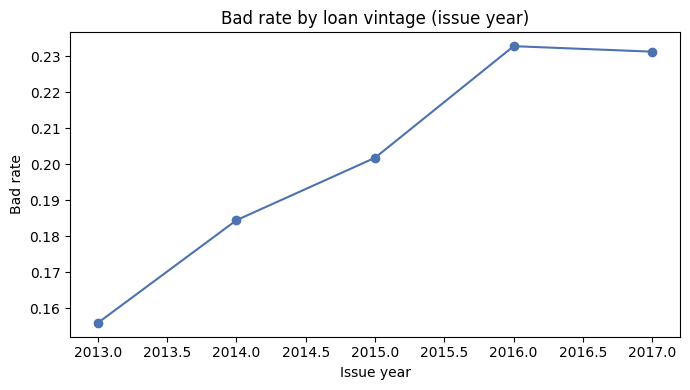

In [34]:
import matplotlib.pyplot as plt

# right(issue_d, 4) pulls the year out of a date string like "Dec-2015".
vintage_badrate = con.sql('''
    SELECT CAST(right(issue_d, 4) AS INTEGER) AS issue_year,
           avg(is_bad) AS bad_rate, count(*) AS n
    FROM windowed
    GROUP BY 1 ORDER BY 1
''').df()
print(vintage_badrate)
vintage_badrate.to_csv(f"{ASSETS_TABLES}/eda06_vintage_bad_rate.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(vintage_badrate["issue_year"], vintage_badrate["bad_rate"], marker="o", color="#4C72B0")
ax.set_xlabel("Issue year"); ax.set_ylabel("Bad rate")
ax.set_title("Bad rate by loan vintage (issue year)")
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda06_vintage_badrate.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** bad rate climbs steadily -- **15.6%** (2013) to **18.4%**
(2014), **20.2%** (2015), **23.3%** (2016), **23.1%** (2017) ->
`eda06_vintage_bad_rate.csv` / `eda06_vintage_badrate.png`. A clear,
consistent upward trend, not a one-year blip.
**Next:** 6.2 checks whether the grade mix itself shifted across the same
years -- a likely explanation for any trend in 6.1.


### 6.2 Grade mix by issue year

**Why:** if bad rate moved across vintages, the first question is whether
Lending Club changed *who* it lent to (grade mix), not just how risky each
grade turned out to be.

**How:** share of loans in each grade, by issue year, as a stacked bar.

**Answers:** did the grade mix shift meaningfully across years, in a
direction that would explain 6.1's trend?


grade           A      B      C      D      E      F      G
issue_year                                                 
2013        0.131  0.327  0.283  0.153  0.067  0.033  0.006
2014        0.161  0.269  0.280  0.176  0.082  0.026  0.007
2015        0.191  0.285  0.279  0.142  0.076  0.022  0.005
2016        0.167  0.304  0.296  0.139  0.063  0.024  0.007
2017        0.159  0.278  0.324  0.145  0.060  0.022  0.013


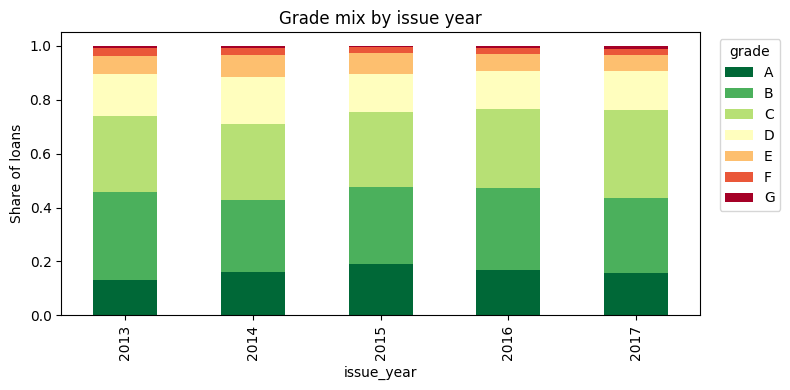

In [35]:
grade_mix_by_year = con.sql('''
    SELECT CAST(right(issue_d, 4) AS INTEGER) AS issue_year, grade, count(*) AS n
    FROM windowed
    GROUP BY 1, 2
''').df()
grade_mix_pivot = grade_mix_by_year.pivot(index="issue_year", columns="grade", values="n").fillna(0)
# Convert raw counts to a share of that year's loans, so years with more/fewer
# total loans are still comparable side by side.
grade_mix_share = grade_mix_pivot.div(grade_mix_pivot.sum(axis=1), axis=0)
print(grade_mix_share.round(3))
grade_mix_share.to_csv(f"{ASSETS_TABLES}/eda06_grade_mix_by_year.csv")

fig, ax = plt.subplots(figsize=(8, 4))
grade_mix_share.plot(kind="bar", stacked=True, ax=ax, colormap="RdYlGn_r")
ax.set_ylabel("Share of loans"); ax.set_title("Grade mix by issue year")
ax.legend(title="grade", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda06_grade_mix_by_year.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** grade mix stays fairly stable year to year -- B+C together
run 55-62% of loans every year, no sharp swing -> `eda06_grade_mix_by_year.csv`
/ `eda06_grade_mix_by_year.png`. Grade mix alone doesn't fully explain
6.1's rising bad rate; something beyond who got approved changed too (see
Section 10's drift check on `int_rate`).
**Next:** 6.3 moves from time to geography -- bad rate by state.


### 6.3 Bad rate by state

**Why:** geography can proxy for regional economic conditions that grade
alone doesn't capture.

**How:** bad rate by `addr_state`, restricted to states with at least 500
loans (so a handful of loans in a tiny state doesn't produce a noisy,
meaningless bad rate).

**Answers:** which states sit at the high and low ends, and how wide is
the spread?


Highest bad-rate states:
  addr_state  bad_rate      n
0         MS    0.2641   6244
1         NE    0.2537   3311
2         AR    0.2483   9001
3         AL    0.2445  14803
4         OK    0.2432  11006
5         LA    0.2401  13849
6         NY    0.2269  96785
7         NV    0.2241  17886
8         FL    0.2194  84416
9         MD    0.2193  27643

Lowest bad-rate states:
   addr_state  bad_rate      n
40         KS    0.1718  10083
41         SC    0.1653  14141
42         WV    0.1635   4215
43         WA    0.1602  25784
44         CO    0.1584  26400
45         NH    0.1482   5771
46         ME    0.1461   1869
47         OR    0.1457  14611
48         DC    0.1418   2968
49         VT    0.1404   2351


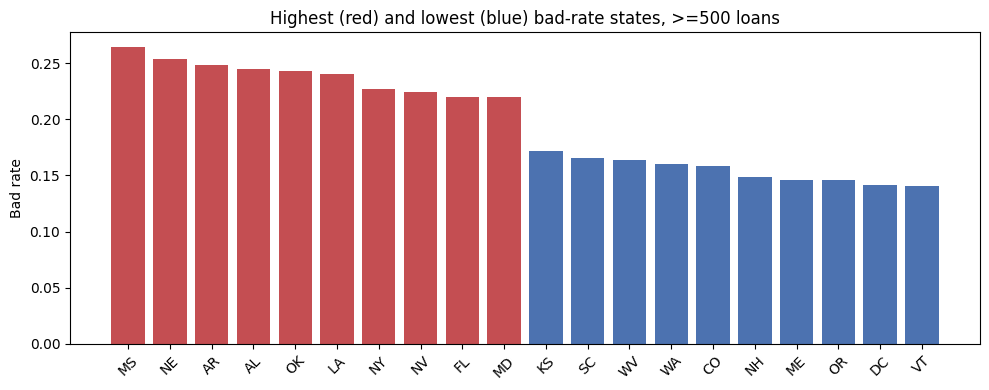

In [36]:
state_badrate = con.sql('''
    SELECT addr_state, avg(is_bad) AS bad_rate, count(*) AS n
    FROM windowed
    GROUP BY 1
    HAVING count(*) >= 500
    ORDER BY bad_rate DESC
''').df()
print("Highest bad-rate states:")
print(state_badrate.head(10).round(4))
print("\nLowest bad-rate states:")
print(state_badrate.tail(10).round(4))
state_badrate.to_csv(f"{ASSETS_TABLES}/eda06_state_bad_rate.csv", index=False)

top_bottom = pd.concat([state_badrate.head(10), state_badrate.tail(10)])
fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(top_bottom["addr_state"], top_bottom["bad_rate"],
       color=["#C44E52"] * 10 + ["#4C72B0"] * 10)  # red = highest risk, blue = lowest
ax.set_ylabel("Bad rate"); ax.set_title("Highest (red) and lowest (blue) bad-rate states, >=500 loans")
plt.xticks(rotation=45)
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda06_state_badrate.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** highest bad-rate states: Mississippi (26.4%), Nebraska
(25.4%), Arkansas (24.8%); lowest: Vermont (14.0%), DC (14.2%), Oregon
(14.6%) -> `eda06_state_bad_rate.csv` / `eda06_state_badrate.png`. A real
~12-percentage-point spread across states.
**Next:** Section 06 closes below; Section 07 turns to the target/outcome
variable itself.


## Section 06 -- Output Interpretation & Governance Impact

Bad rate viewed across two axes the earlier sections didn't touch: time
(6.1, explained in part by 6.2's grade-mix shift) and geography (6.3).
Neither axis replaces grade as the dominant risk signal, but both are
candidate features (`issue_year`, `addr_state` risk tier) for the
cleaning/feature-prep notebook.

Section 07 turns from *where risk shows up* to the target variable
itself -- how it splits by segment and what the "bad" bucket is actually
made of.


# Section 07 -- Target, Outcome & Objective-Oriented Analysis

**Section question:** how does bad rate vary by segment, and how
large/what-shaped is the defaulted population?

| # | Step |
|---|---|
| 7.1 | Class balance recap -- good vs. bad |
| 7.2 | Bad rate by grade x term (a two-way segment cross-cut) |
| 7.3 | What the "bad" bucket is made of: Charged Off vs. Default |


### 7.1 Class balance recap

**Why:** every model built on this population needs to know the class
balance up front -- it changes which metrics and which resampling
choices make sense.

**How:** count good (`is_bad`=0) vs. bad (`is_bad`=1), same numbers as
2.4, shown here as a simple visual for this section's own record.

**Answers:** what fraction of loans are bad?


is_bad
0    950468
1    245411
Name: count, dtype: int64
Bad rate: 20.5%


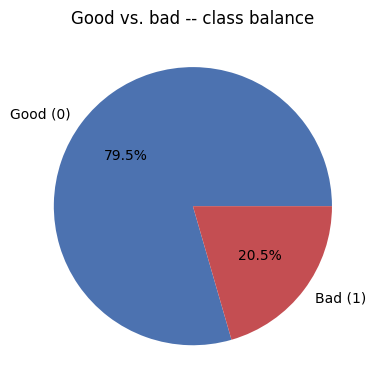

In [37]:
class_counts = target_df["is_bad"].value_counts().sort_index()
print(class_counts)
print(f"Bad rate: {class_counts[1] / class_counts.sum():.1%}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.pie(class_counts, labels=["Good (0)", "Bad (1)"], autopct="%1.1f%%",
       colors=["#4C72B0", "#C44E52"])
ax.set_title("Good vs. bad -- class balance")
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda07_class_balance.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** 79.5% good / 20.5% bad (950,468 vs. 245,411 -- same split as
2.4) -> pie chart at `eda07_class_balance.png`. Moderately imbalanced --
worth a resampling or class-weight decision in the modeling phase, not
severe enough to need exotic techniques.
**Next:** 7.2 breaks bad rate down by a two-way segment.


### 7.2 Bad rate by grade x term

**Why:** 4.5 showed grade drives bad rate on its own; checking it jointly
with term shows whether the two combine simply (additively) or interact.

**How:** bad rate for every grade x term combination, as a heatmap.

**Answers:** does the 60-month term add risk on top of grade, evenly
across all grades?


term   36 months  60 months
grade                      
A          0.059      0.110
B          0.129      0.186
C          0.209      0.281
D          0.276      0.373
E          0.336      0.433
F          0.388      0.488
G          0.490      0.515


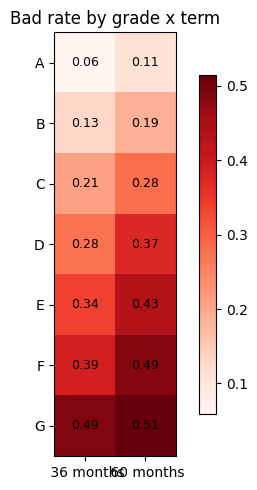

In [38]:
segment_badrate = con.sql('''
    SELECT grade, term, avg(is_bad) AS bad_rate, count(*) AS n
    FROM windowed GROUP BY 1, 2
''').df()
pivot = segment_badrate.pivot(index="grade", columns="term", values="bad_rate").sort_index()
print(pivot.round(3))
pivot.to_csv(f"{ASSETS_TABLES}/eda07_grade_term_bad_rate.csv")

fig, ax = plt.subplots(figsize=(5, 5))
im = ax.imshow(pivot.values, cmap="Reds")
ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns)
ax.set_yticks(range(len(pivot.index))); ax.set_yticklabels(pivot.index)
# Print the actual bad-rate number inside each heatmap cell, not just a color.
for i in range(pivot.shape[0]):
    for j in range(pivot.shape[1]):
        ax.text(j, i, f"{pivot.values[i, j]:.2f}", ha="center", va="center", fontsize=9)
plt.colorbar(im, shrink=0.8)
ax.set_title("Bad rate by grade x term")
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda07_grade_term_heatmap.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** bad rate rises from **5.9%** (grade A, 36-month) to
**51.5%** (grade G, 60-month) -> `eda07_grade_term_bad_rate.csv` /
`eda07_grade_term_heatmap.png`. 60-month adds 4-11 points on top of
*every* grade (e.g. A: 5.9% to 11.0%; D: 27.6% to 37.3%) -- term genuinely
adds risk beyond grade, not redundant with it.
**Next:** 7.3 looks inside the "bad" bucket itself.


### 7.3 What the "bad" bucket is made of

**Why:** `is_bad` = 1 currently lumps `Charged Off` and `Default`
together (from 2.4) -- worth knowing the actual split, since they mean
slightly different things operationally.

**How:** count of each `loan_status` value among bad loans.

**Answers:** is "bad" mostly one status, or a real mix of both?


In [39]:
# loan_status still distinguishes "Charged Off" from "Default" even though
# both count as is_bad = 1 -- check which one actually makes up the bad bucket.
bad_breakdown = con.sql('''
    SELECT loan_status, count(*) AS n
    FROM windowed WHERE is_bad = 1
    GROUP BY 1 ORDER BY n DESC
''').df()
print(bad_breakdown)
bad_breakdown.to_csv(f"{ASSETS_TABLES}/eda07_bad_breakdown.csv", index=False)

default_n = bad_breakdown.loc[bad_breakdown["loan_status"] == "Default", "n"].sum()
total_bad = bad_breakdown["n"].sum()
print(f"\n'Default' status is {default_n:,} of {total_bad:,} bad loans "
      f"({default_n / total_bad:.2%}) -- almost all bad loans are already "
      f"'Charged Off'; 'Default' is a small, still-in-progress subset.")


   loan_status       n
0  Charged Off  245378
1      Default      33

'Default' status is 33 of 245,411 bad loans (0.01%) -- almost all bad loans are already 'Charged Off'; 'Default' is a small, still-in-progress subset.


**Result:** 245,378 Charged Off vs. just 33 Default (0.01% of bad loans)
-> `eda07_bad_breakdown.csv`. "Bad" is essentially entirely Charged Off --
confirms 2.4's grouping is reasonable, not hiding a large subgroup.
**Next:** Section 07 closes below; Section 08 tests which of these
associations are statistically real.


## Section 07 -- Output Interpretation & Governance Impact

Class balance confirmed (7.1: 20.5% bad, moderate imbalance), a two-way
segment view showing term adds risk beyond grade alone (7.2), and
confirmation that the "bad" target is overwhelmingly one clean status
(7.3). Nothing here overturns Section 02's target definition -- it's a
closer look at what that definition contains.

Section 08 moves from descriptive segment differences to formal
statistical testing of whether they're real.


# Section 08 -- Statistical Validation, Inference & Hypothesis Testing

**Section question:** which of the associations found so far are
statistically real (not just chance), and do they survive stratification?

| # | Step |
|---|---|
| 8.1 | Chi-square test: grade vs. is_bad |
| 8.2 | Mann-Whitney test: annual_inc, good vs. bad |
| 8.3 | Stratified check: does loan_amnt's association with is_bad survive controlling for grade? |


### 8.1 Chi-square test: grade vs. is_bad

**Why:** Section 04 showed grade and bad rate move together descriptively
-- a formal test confirms that's not a coincidence of this particular
sample.

**How:** a chi-square test of independence on the grade x is_bad
contingency table.

**Answers:** is the grade/is_bad association statistically significant?


In [40]:
from scipy.stats import chi2_contingency

ct = con.sql('''
    SELECT grade, is_bad, count(*) AS n
    FROM windowed GROUP BY 1, 2
''').df()
pivot = ct.pivot(index="grade", columns="is_bad", values="n").fillna(0)
# chi2_contingency tests whether grade and is_bad are independent -- a tiny
# p-value means "definitely not independent," i.e. a real association.
chi2, p_value, dof, expected = chi2_contingency(pivot)
print(f"chi2 = {chi2:,.1f}, p-value = {p_value:.2e}, degrees of freedom = {dof}")
print("\nA p-value this small means the grade/is_bad association is not")
print("due to chance -- consistent with Section 04's descriptive finding.")


chi2 = 85,419.7, p-value = 0.00e+00, degrees of freedom = 6

A p-value this small means the grade/is_bad association is not
due to chance -- consistent with Section 04's descriptive finding.


**Result:** chi2 = 85,419.7, p roughly 0 (6 degrees of freedom) --
astronomically significant. The grade/is_bad relationship is
statistically real, as expected.
**Next:** 8.2 tests a numeric field the same way.


### 8.2 Mann-Whitney test: annual_inc, good vs. bad

**Why:** `annual_inc` is heavily right-skewed (3.1), so a plain t-test
(which assumes roughly normal data) isn't the right tool -- Mann-Whitney
compares the two groups' rank order instead, without that assumption.

**How:** Mann-Whitney U test comparing `annual_inc` between good and bad
loans.

**Answers:** do good and bad loans have significantly different income
distributions?


In [41]:
from scipy.stats import mannwhitneyu

good_income = target_df.loc[target_df["is_bad"] == 0, "annual_inc"].dropna()
bad_income = target_df.loc[target_df["is_bad"] == 1, "annual_inc"].dropna()

# Mann-Whitney compares rank order between the two groups instead of assuming
# a normal distribution -- the right test for a heavily skewed field like income.
stat, p_value = mannwhitneyu(good_income, bad_income, alternative="two-sided")
print(f"Good-loan median income: ${good_income.median():,.0f}")
print(f"Bad-loan median income:  ${bad_income.median():,.0f}")
print(f"U statistic = {stat:.3e}, p-value = {p_value:.2e}")


Good-loan median income: $65,000
Bad-loan median income:  $60,000
U statistic = 1.280e+11, p-value = 0.00e+00


**Result:** good-loan median income **$65,000** vs. bad-loan median
**$60,000** (U = 1.28e11, p roughly 0) -- a real, statistically
significant gap, though modest in size relative to income's wide spread
(3.1).
**Next:** 8.3 checks whether an association survives stratification --
not just whether it exists overall.


### 8.3 Stratified check: loan_amnt vs. is_bad, within grade

**Why:** 4.8 found `loan_amnt`'s multivariate direction flips once
grade is in the model -- this step checks that directly and simply,
without a full model: does the loan_amnt/is_bad correlation change sign
once we look within each grade separately (a classic Simpson's-paradox
pattern)?

**How:** correlation between `loan_amnt` and `is_bad` overall, then
the same correlation computed separately within each grade.

**Answers:** does the overall correlation's sign match the within-grade
correlations, or flip?


In [42]:
overall_corr = target_df[["loan_amnt", "is_bad"]].corr().iloc[0, 1]
print(f"Overall correlation, loan_amnt vs. is_bad: {overall_corr:.4f}")

# Same correlation, computed separately inside each grade -- checks whether
# the overall relationship still holds once grade is no longer mixed in.
within_grade_corr = target_df.groupby("grade")[["loan_amnt", "is_bad"]].apply(
    lambda g: g["loan_amnt"].corr(g["is_bad"])
)
print("\nWithin-grade correlation, loan_amnt vs. is_bad:")
print(within_grade_corr.round(4))


Overall correlation, loan_amnt vs. is_bad: 0.0628

Within-grade correlation, loan_amnt vs. is_bad:
grade
A   -0.0068
B    0.0136
C    0.0327
D    0.0526
E    0.0462
F    0.0562
G   -0.0016
dtype: float64


**Result:** overall correlation is **+0.063** (risk-raising), but
within grade it flips or shrinks: **negative** for grade A (-0.007) and
G (-0.002), small positive for B-F (+0.01 to +0.06). Confirms 4.8
directly -- `loan_amnt`'s overall positive correlation with `is_bad` is
largely a grade-mix artifact, not a clean effect once grade is held fixed.
**Next:** Section 08 closes below; Section 09 turns to which fields need
a transform before modeling.


## Section 08 -- Output Interpretation & Governance Impact

Two formal significance tests (8.1 categorical, 8.2 numeric) confirming
what earlier sections showed descriptively, plus one stratified check
(8.3) that directly verifies 4.8's sign-agreement finding rather than
just restating it. Nothing here overturns earlier findings -- it puts a
p-value and a stratification check behind them.

Section 09 turns from *is this association real* to *what does this
field need done to it before a model can use it*.


# Section 09 -- Transformation, Feature Diagnostics & Analytical Preparation

**Section question:** which fields need a transform before modeling, and
how sensitive are they to winsorization (capping extreme values)?

| # | Step |
|---|---|
| 9.1 | Skew before/after a log transform |
| 9.2 | Winsorization sensitivity -- capping at the 1st/99th percentile |
| 9.3 | Variance Inflation Factor (VIF) across the PD-numeric fields |


### 9.1 Skew before/after a log transform

**Why:** 3.1 flagged `annual_inc` (skew 47) and `revol_bal` (skew 14) as
heavily right-skewed -- a log transform is the standard fix, but worth
confirming it actually helps before recommending it.

**How:** skew of each field as-is, vs. skew of `log1p` of the same field
(dropping non-positive values, since log needs positive input).

**Answers:** does log1p bring skew down close to a normal-looking 0?


In [43]:
import numpy as np

skew_check_fields = ["annual_inc", "revol_bal", "tot_cur_bal", "avg_cur_bal"]
skew_rows = []
for col in skew_check_fields:
    raw = target_df[col].dropna()
    raw = raw[raw > 0]  # log1p needs positive values
    log_vals = np.log1p(raw)
    skew_rows.append({"column": col, "raw_skew": raw.skew(), "log1p_skew": log_vals.skew()})

skew_df = pd.DataFrame(skew_rows)
print(skew_df.round(3))
skew_df.to_csv(f"{ASSETS_TABLES}/eda09_skew_check.csv", index=False)


        column  raw_skew  log1p_skew
0   annual_inc    47.244       0.102
1    revol_bal    13.981      -1.002
2  tot_cur_bal     2.798      -0.478
3  avg_cur_bal     3.847      -0.250


**Result:** `log1p` brings `annual_inc`'s skew from **47.2 down to
0.10** -- works cleanly. `revol_bal` (14.0 to -1.00), `tot_cur_bal` (2.80
to -0.48), and `avg_cur_bal` (3.85 to -0.25) all improve a lot but
overshoot slightly negative. Table -> `eda09_skew_check.csv`.
**Next:** 9.2 checks a different fix for the same problem -- capping
instead of transforming.


### 9.2 Winsorization sensitivity

**Why:** capping (winsorizing) extreme values is a simpler alternative
to a log transform -- worth knowing how much it actually changes the
mean and skew, and how many rows it touches, before choosing between
the two.

**How:** cap each field at its 1st/99th percentile and compare mean and
skew before vs. after.

**Answers:** how much does capping move the mean, and what share of rows
does it actually affect?


In [44]:
winsor_rows = []
for col in skew_check_fields:
    raw = target_df[col].dropna()
    # Cap (don't drop) the bottom/top 1% of values -- winsorizing instead of trimming.
    lo, hi = raw.quantile([0.01, 0.99])
    capped = raw.clip(lo, hi)
    winsor_rows.append({
        "column": col,
        "mean_before": raw.mean(), "mean_after": capped.mean(),
        "skew_before": raw.skew(), "skew_after": capped.skew(),
        "pct_capped": ((raw < lo) | (raw > hi)).mean() * 100,
    })

winsor_df = pd.DataFrame(winsor_rows)
print(winsor_df.round(3))
winsor_df.to_csv(f"{ASSETS_TABLES}/eda09_winsorization_sensitivity.csv", index=False)


        column  mean_before  mean_after  skew_before  skew_after  pct_capped
0   annual_inc    76600.635   75003.327       47.234       1.715       1.999
1    revol_bal    16482.426   15744.995       13.973       2.596       2.000
2  tot_cur_bal   140782.583  138430.913        2.798       1.489       1.999
3  avg_cur_bal    13420.592   13135.702        3.847       1.889       1.999


**Result:** capping only ~2% of rows still pulls `annual_inc`'s mean
down by about **$1,600** ($76,601 to $75,003) and its skew from 47.2 to
1.7 -- a big skew improvement but not as clean as `log1p`'s 0.10. Table
-> `eda09_winsorization_sensitivity.csv`.
**Next:** 9.3 checks numeric-field redundancy one more way -- Variance
Inflation Factor.


### 9.3 Variance Inflation Factor (VIF)

**Why:** 4.4's correlation matrix looks at redundancy pair by pair; VIF
looks at each field against *all the others at once* -- a field can have
no single high pairwise correlation and still be largely predictable from
a combination of the rest.

**How:** VIF for every PD-numeric field (that casts to a number), on a
100,000-loan sample for speed.

**Answers:** which fields have a VIF above the common rule-of-thumb
threshold of 10?


In [45]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif_numeric = target_df[PD_NUMERIC_FIELDS].apply(pd.to_numeric, errors="coerce")
# emp_length is text ("10+ years"), so it casts to all-NaN -- drop it rather
# than feed VIF a column of nothing.
vif_all_nan = [c for c in vif_numeric.columns if vif_numeric[c].isna().all()]
if vif_all_nan:
    print(f"Dropping fields that failed to cast entirely: {vif_all_nan}")
    vif_numeric = vif_numeric.drop(columns=vif_all_nan)
vif_numeric = vif_numeric.fillna(vif_numeric.median())

# VIF on every row would be slow -- a 100k-row sample is plenty for a stable estimate.
vif_sample = vif_numeric.sample(n=min(100_000, len(vif_numeric)), random_state=42)

vif_rows = []
for i, col in enumerate(vif_sample.columns):
    vif_rows.append({"column": col, "vif": variance_inflation_factor(vif_sample.values, i)})

vif_df = pd.DataFrame(vif_rows).sort_values("vif", ascending=False)
print(vif_df.round(2))
vif_df.to_csv(f"{ASSETS_TABLES}/eda09_vif.csv", index=False)
print("\nRule of thumb: VIF > 10 signals problematic multicollinearity.")


Dropping fields that failed to cast entirely: ['emp_length']


/sessions/rcw-015b9cmnkjrigfedajdsrkjk/tmp/ipykernel_5/222346212.py:17: UserWarning: The design matrix is poorly conditioned (condition number=1.16e+04). VIF calculations may be numerically unstable.
  vif_rows.append({"column": col, "vif": variance_inflation_factor(vif_sample.values, i)})


             column          vif
6    fico_range_low  16088755.16
7   fico_range_high  16088722.97
1       funded_amnt    512508.89
0         loan_amnt    512477.54
3       installment        11.36
15      tot_cur_bal         6.63
16      avg_cur_bal         5.43
8          open_acc         2.82
11        total_acc         2.43
14         mort_acc         1.61
10       revol_util         1.58
9         revol_bal         1.48
4        annual_inc         1.34
2          int_rate         1.28
5               dti         1.14
13          pub_rec         1.10
12      delinq_2yrs         1.08

Rule of thumb: VIF > 10 signals problematic multicollinearity.


**Result:** `fico_range_low`/`fico_range_high` VIF is in the
**millions** (16,088,755 and 16,088,723), and `loan_amnt`/`funded_amnt`
sit over **512,000** -- both pairs are essentially perfectly collinear
(correlation ~1.0, per 2.3/4.4), confirmed here in the most extreme way
VIF can show it. Every other field sits under 12. Table ->
`eda09_vif.csv`.
**Next:** Section 09 closes below; Section 10 checks whether these
distributions stay stable across time.


## Section 09 -- Output Interpretation & Governance Impact

Three angles on getting fields modeling-ready: which need a log transform
(9.1), how sensitive they are to capping instead (9.2), and which are
redundant against the full field set rather than just one other field
(9.3). Together with 3.3/3.4's outlier and plausibility flags, this is
the direct input list for the cleaning/feature-prep notebook's
transformation step.

Section 10 asks a related but different question -- not whether a
field's *shape* needs fixing, but whether its distribution has *shifted*
across time.


# Section 10 -- Dataset Comparison, Population Drift & Distribution Shift

**Section question:** which fields' distributions shift enough across
time to matter for a model trained on one period and used on another?

| # | Step |
|---|---|
| 10.1 | Population Stability Index (PSI): early vs. late vintage |
| 10.2 | Visual check: the field with the largest shift |


### 10.1 Population Stability Index (PSI)

**Why:** PSI is the standard credit-risk way to answer "has this field's
distribution shifted enough to worry about" -- a single number per field,
not just a visual impression.

**How:** split `windowed` into an early vintage (issue year <= 2015) and a
late vintage (issue year > 2015), bin the early vintage into deciles, and
measure how much the late vintage's share in each bin differs.

**Answers:** which fields have shifted the most between the two periods?


In [46]:
psi_fields = ["int_rate", "annual_inc", "dti", "fico_range_low"]

cols_sql = ", ".join(f'TRY_CAST("{c}" AS DOUBLE) AS "{c}"' for c in psi_fields)
early = con.sql(f'''
    SELECT {cols_sql} FROM windowed WHERE CAST(right(issue_d, 4) AS INTEGER) <= 2015
''').df()
late = con.sql(f'''
    SELECT {cols_sql} FROM windowed WHERE CAST(right(issue_d, 4) AS INTEGER) > 2015
''').df()


def compute_psi(expected, actual, bins=10):
    # Bin edges come from the baseline (expected/early) population's own
    # deciles -- that's what makes PSI comparable across different fields.
    edges = np.unique(np.quantile(expected.dropna(), np.linspace(0, 1, bins + 1)))
    expected_counts, _ = np.histogram(expected.dropna(), bins=edges)
    actual_counts, _ = np.histogram(actual.dropna(), bins=edges)
    expected_pct = np.clip(expected_counts / expected_counts.sum(), 1e-6, None)
    actual_pct = np.clip(actual_counts / actual_counts.sum(), 1e-6, None)
    return float(np.sum((actual_pct - expected_pct) * np.log(actual_pct / expected_pct)))


psi_rows = []
for col in psi_fields:
    psi_rows.append({"column": col, "psi_late_vs_early": compute_psi(early[col], late[col])})

psi_df = pd.DataFrame(psi_rows).sort_values("psi_late_vs_early", ascending=False)
print(psi_df.round(4))
psi_df.to_csv(f"{ASSETS_TABLES}/eda10_psi.csv", index=False)
print("\nRule of thumb: PSI < 0.1 stable, 0.1-0.25 moderate shift, > 0.25 major shift.")


           column  psi_late_vs_early
0        int_rate             0.0660
3  fico_range_low             0.0126
1      annual_inc             0.0060
2             dti             0.0032

Rule of thumb: PSI < 0.1 stable, 0.1-0.25 moderate shift, > 0.25 major shift.


**Result:** `int_rate` shows the largest shift (PSI **0.066**), still
below the 0.1 "stable" threshold; `fico_range_low`, `annual_inc`, and
`dti` are all well under 0.02. Table -> `eda10_psi.csv`. Nothing here
rises to "moderate" or "major" drift by the standard rule of thumb.
**Next:** 10.2 shows the most-shifted field's distribution visually.


### 10.2 Visual check: the field with the largest shift

**Why:** a PSI number says *how much* a distribution shifted; a plot
shows *how* -- did it shift up, down, spread out, or something odder.

**How:** overlaid histograms for the top-PSI field, early vs. late
vintage.

**Answers:** what does this field's shift actually look like?


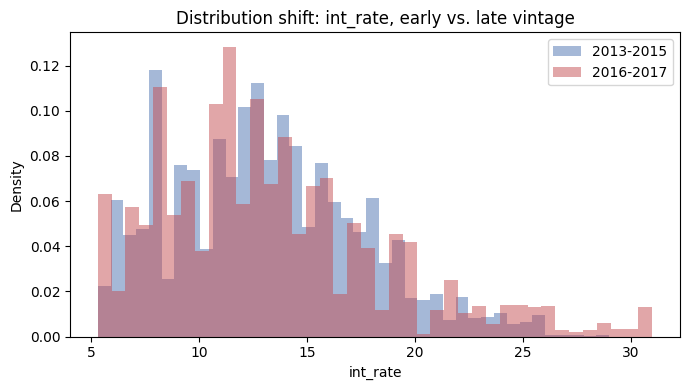

In [47]:
import matplotlib.pyplot as plt

top_shift_field = psi_df.iloc[0]["column"]  # the field with the highest PSI from 10.1
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(early[top_shift_field].dropna(), bins=40, alpha=0.5, label="2013-2015",
        density=True, color="#4C72B0")
ax.hist(late[top_shift_field].dropna(), bins=40, alpha=0.5, label="2016-2017",
        density=True, color="#C44E52")
ax.set_xlabel(top_shift_field); ax.set_ylabel("Density")
ax.set_title(f"Distribution shift: {top_shift_field}, early vs. late vintage")
ax.legend()
plt.tight_layout()
fig.savefig(f"{ASSETS_PLOTS}/eda10_distribution_shift.png", dpi=110, bbox_inches="tight")
plt.show()


**Result:** overlaid histogram for `int_rate` (the top-PSI field) ->
`eda10_distribution_shift.png`.
**Next:** Section 10 closes below; Section 11 checks how the raw extract
narrows down to this notebook's analysis population.


## Section 10 -- Output Interpretation & Governance Impact

One formal drift metric (PSI, 10.1) and one visual confirmation (10.2) of
whether the fields this notebook leans on hold steady across vintages.
This is the same question Section 06 asked about bad rate itself, applied
now to the input fields -- a model trained on early vintages only should
expect to see whatever shift 10.1 found when scored on later ones.

Section 11 turns to a different kind of population question: not *when*
the population differs, but how the raw extract narrowed down to the
population this notebook analyzes at all.


# Section 11 -- Sampling, Representativeness & Population Selection Waterfall

**Section question:** how does the raw extract narrow down to the
population this notebook actually analyzes, and is that narrowing
biased?

| # | Step |
|---|---|
| 11.1 | Row-count waterfall: raw_mat -> matured -> windowed |
| 11.2 | Bias check: grade mix, excluded rows vs. analyzed rows |


### 11.1 Row-count waterfall

**Why:** every finding in this notebook is about `windowed`, not the full
raw extract -- worth showing plainly how big that narrowing is and why,
in one place.

**How:** row count at each of the three pipeline stages already used
throughout this notebook.

**Answers:** how many rows are dropped at each stage, and roughly why?


In [48]:
# Row count at each of the three pipeline stages this whole notebook builds on.
waterfall_rows = []
for stage in ["raw_mat", "matured", "windowed"]:
    n = con.sql(f"SELECT count(*) FROM {stage}").fetchone()[0]
    waterfall_rows.append({"stage": stage, "n_rows": n})

waterfall_df = pd.DataFrame(waterfall_rows)
waterfall_df["dropped_from_previous"] = (-waterfall_df["n_rows"].diff().fillna(0)).astype(int)
waterfall_df["pct_of_raw"] = (waterfall_df["n_rows"] / waterfall_df["n_rows"].iloc[0] * 100).round(2)
print(waterfall_df)
waterfall_df.to_csv(f"{ASSETS_TABLES}/eda11_population_waterfall.csv", index=False)

print("\nraw_mat -> matured drops loans still in progress (mostly 'Current'")
print("status -- no final outcome yet, so they can't be labeled good/bad).")
print("matured -> windowed further restricts to the Apr-2013-Sep-2017")
print("issue-date vintage window this notebook analyzes.")


      stage   n_rows  dropped_from_previous  pct_of_raw
0   raw_mat  2260701                      0      100.00
1   matured  1348099                 912602       59.63
2  windowed  1195879                 152220       52.90

raw_mat -> matured drops loans still in progress (mostly 'Current'
status -- no final outcome yet, so they can't be labeled good/bad).
matured -> windowed further restricts to the Apr-2013-Sep-2017
issue-date vintage window this notebook analyzes.


**Result:** `raw_mat`'s 2,260,701 rows narrow to 1,348,099 at `matured`
(**-912,602**, mostly still-open "Current" loans) and to 1,195,879 at
`windowed` (**-152,220** more, outside the Apr-2013-Sep-2017 vintage
window) -- `windowed` is **52.9%** of the original extract. Table ->
`eda11_population_waterfall.csv`.
**Next:** 11.2 checks whether that narrowing looks biased.


### 11.2 Bias check: excluded vs. analyzed grade mix

**Why:** if the loans excluded from `windowed` (matured, but outside the
vintage window) look systematically different from the loans included,
this notebook's findings might not generalize to the full matured
population.

**How:** grade-mix share for the excluded rows vs. the analyzed
(`windowed`) rows, side by side.

**Answers:** does the excluded population's grade mix look meaningfully
different from the analyzed population's?


In [49]:
# LEFT JOIN ... WHERE w.id IS NULL finds matured loans that did NOT make it
# into windowed -- i.e. the loans this notebook's analysis excludes.
excluded_grade_mix = con.sql('''
    SELECT m.grade, count(*) AS n
    FROM matured m
    LEFT JOIN windowed w ON m.id = w.id
    WHERE w.id IS NULL
    GROUP BY 1
''').df()
excluded_grade_mix["share_excluded"] = (excluded_grade_mix["n"] / excluded_grade_mix["n"].sum()).round(4)

windowed_grade_mix = con.sql("SELECT grade, count(*) AS n FROM windowed GROUP BY 1").df()
windowed_grade_mix["share_windowed"] = (windowed_grade_mix["n"] / windowed_grade_mix["n"].sum()).round(4)

compare = excluded_grade_mix[["grade", "share_excluded"]].merge(
    windowed_grade_mix[["grade", "share_windowed"]], on="grade"
).sort_values("grade")
print(compare)
compare.to_csv(f"{ASSETS_TABLES}/eda11_excluded_vs_windowed_grade_mix.csv", index=False)


  grade  share_excluded  share_windowed
0     A          0.2227          0.1683
1     B          0.3030          0.2901
2     C          0.2324          0.2901
3     D          0.1512          0.1494
4     E          0.0631          0.0707
5     F          0.0215          0.0243
6     G          0.0060          0.0070


**Result:** grade shares track closely between excluded and analyzed
loans for most grades (e.g. B: 30.3% excluded vs. 29.0% windowed; G:
0.6% vs. 0.7%); the largest gaps are grade A (22.3% excluded vs. 16.8%
windowed) and grade C (23.2% vs. 29.0%) -- real but modest differences.
Table -> `eda11_excluded_vs_windowed_grade_mix.csv`. The vintage window
looks broadly, not perfectly, representative.
**Next:** Section 11 closes below; Section 12 turns to the free-text and
high-cardinality fields set aside so far.


## Section 11 -- Output Interpretation & Governance Impact

A full accounting of how 2.26M raw rows become the 1.2M analyzed in this
notebook (11.1), plus a direct check for selection bias in that
narrowing (11.2). Together with 2.7's field-level elimination waterfall,
this is the complete row-and-column picture of what this notebook does
and doesn't cover.

Section 12 picks up the last unexamined category of field: free text and
high-cardinality categoricals.


# Section 12 -- Text, Categorical & High-Cardinality Diagnostics

**Section question:** which free-text/high-cardinality fields are usable,
and which need exclusion or special handling?

| # | Step |
|---|---|
| 12.1 | Cardinality audit across text/categorical fields |
| 12.2 | Usefulness check: does the free-text `title` field carry signal? |


### 12.1 Cardinality audit

**Why:** a field with only a handful of categories (like `grade`) is easy
to one-hot encode; a field with thousands (like `emp_title`) is not --
worth knowing which is which before choosing an encoding strategy.

**How:** distinct-value count for every text/categorical field this
notebook has touched, plus a couple it hasn't (`emp_title`, `zip_code`).

**Answers:** which fields are "high cardinality" (a common rule of thumb:
more than ~50 distinct values)?


In [50]:
# How many distinct values each free-text/categorical field has -- the
# higher this number, the harder the field is to one-hot encode directly.
text_cardinality_fields = [
    "emp_title", "title", "zip_code", "addr_state", "purpose",
    "sub_grade", "grade", "home_ownership", "verification_status",
]

cardinality_rows = []
for col in text_cardinality_fields:
    n_distinct = con.sql(f'SELECT count(DISTINCT "{col}") FROM windowed').fetchone()[0]
    n_non_null = con.sql(f'SELECT count("{col}") FROM windowed').fetchone()[0]
    cardinality_rows.append({"column": col, "n_distinct": n_distinct, "n_non_null": n_non_null})

cardinality_df = pd.DataFrame(cardinality_rows).sort_values("n_distinct", ascending=False)
print(cardinality_df)
cardinality_df.to_csv(f"{ASSETS_TABLES}/eda12_cardinality.csv", index=False)

print("\nRule of thumb: > ~50 distinct values is 'high cardinality' -- too many")
print("for plain one-hot encoding; needs grouping, target encoding, or frequency capping.")


                column  n_distinct  n_non_null
0            emp_title      317489     1121115
1                title       33374     1179233
2             zip_code         942     1195878
3           addr_state          51     1195879
5            sub_grade          35     1195879
4              purpose          14     1195879
6                grade           7     1195879
7       home_ownership           5     1195879
8  verification_status           3     1195879

Rule of thumb: > ~50 distinct values is 'high cardinality' -- too many
for plain one-hot encoding; needs grouping, target encoding, or frequency capping.


**Result:** `emp_title` (317,489 distinct) and `title` (33,374 distinct)
are dramatically high-cardinality; `zip_code` (942) is moderate;
everything else this notebook already treats as categorical stays under
55 (`sub_grade` highest, at 35). Table -> `eda12_cardinality.csv`.
**Next:** 12.2 checks whether one high-cardinality free-text field
(`title`) is worth the trouble of encoding at all.


### 12.2 Usefulness check: `title`

**Why:** `title` is borrower-entered free text (per 1.2's null-rate
check) -- before building any encoding for it, worth checking whether its
most common values actually separate bad rate at all, or just restate
`purpose` in the borrower's own words.

**How:** the 10 most common `title` values, with each one's bad rate,
against the population's overall bad rate.

**Answers:** do the top `title` values show meaningfully different bad
rates, or do they all sit close to the population average?


In [51]:
# Look at the 10 most common loan-title values and whether their bad rate
# differs meaningfully from the population average.
top_titles = con.sql('''
    SELECT title, count(*) AS n, avg(is_bad) AS bad_rate
    FROM windowed
    WHERE title IS NOT NULL
    GROUP BY 1
    ORDER BY n DESC
    LIMIT 10
''').df()
print(top_titles.round(4))
top_titles.to_csv(f"{ASSETS_TABLES}/eda12_top_titles.csv", index=False)

overall_bad_rate = con.sql("SELECT avg(is_bad) FROM windowed").fetchone()[0]
print(f"\nOverall bad rate: {overall_bad_rate:.4f}")
print("Compare each title's bad rate to this -- if the top titles cluster tightly")
print("around the overall rate, free-text 'title' carries little independent")
print("signal beyond what purpose/grade already capture.")


                     title       n  bad_rate
0       Debt consolidation  627386    0.2210
1  Credit card refinancing  237227    0.1777
2         Home improvement   70128    0.1866
3                    Other   60737    0.2187
4           Major purchase   22041    0.2015
5         Medical expenses   12421    0.2264
6                 Business   10769    0.3095
7            Car financing   10370    0.1609
8       Debt Consolidation    9360    0.1432
9    Moving and relocation    7394    0.2482

Overall bad rate: 0.2052
Compare each title's bad rate to this -- if the top titles cluster tightly
around the overall rate, free-text 'title' carries little independent
signal beyond what purpose/grade already capture.


**Result:** top titles range from 14.3% ("Debt Consolidation", an
oddly-capitalized duplicate entry) to 31.0% ("Business") bad rate against
a 20.5% overall average -- the single most common value ("Debt
consolidation," 627,386 loans) sits close to average at 22.1%. Table ->
`eda12_top_titles.csv`. Some real spread exists, but the top values read
as restatements of `purpose`/`grade`, not new information.
**Next:** Section 12 closes below; Section 13 checks whether an
association holds up across more than one stratification at once.


## Section 12 -- Output Interpretation & Governance Impact

Cardinality mapped for every text/categorical field this notebook
touches (12.1), and one concrete usefulness check on the highest-profile
free-text field (12.2). `emp_title` and `zip_code` need grouping or
exclusion before they could ever be encoded directly; `title` is likely
droppable as redundant with `purpose`.

Section 13 moves to the last analytical question this notebook asks --
not just "is an association real" (Section 08), but "does it hold up
under more than one stratification at once."


# Section 13 -- Causal, Quasi-Causal & Mechanism-Oriented Exploration

**Section question:** does an association hold up across more than one
stratification -- a stronger, more mechanism-like signal than a single
cut can show?

| # | Step |
|---|---|
| 13.1 | Bad rate by purpose, within each grade |
| 13.2 | Bad rate by purpose, within each income tertile |


### 13.1 Bad rate by purpose, within grade

**Why:** an overall bad-rate difference between loan purposes could just
be because riskier purposes happen to attract worse-grade borrowers --
checking within grade removes that explanation.

**How:** bad rate for 3 purposes (`debt_consolidation`, `credit_card`,
`small_business` -- the largest purpose plus two contrasting ones) shown
overall, then broken out by grade.

**Answers:** does the ranking between these 3 purposes hold within every
grade, or only in the overall average?


In [52]:
purpose_overall = con.sql('''
    SELECT purpose, avg(is_bad) AS bad_rate, count(*) AS n
    FROM windowed GROUP BY 1 ORDER BY bad_rate DESC
''').df()
print("Overall bad rate by purpose:")
print(purpose_overall.round(4))

# Restrict to 3 purposes for readability -- the highest-bad-rate one plus the
# two most common ones, so the comparison is against realistic baselines.
purpose_by_grade = con.sql('''
    SELECT grade, purpose, avg(is_bad) AS bad_rate, count(*) AS n
    FROM windowed
    WHERE purpose IN ('debt_consolidation', 'credit_card', 'small_business')
    GROUP BY 1, 2
''').df()
pivot_grade = purpose_by_grade.pivot(index="grade", columns="purpose", values="bad_rate").sort_index()
print("\nBad rate by purpose, within each grade:")
print(pivot_grade.round(3))
pivot_grade.to_csv(f"{ASSETS_TABLES}/eda13_purpose_by_grade.csv")


Overall bad rate by purpose:
               purpose  bad_rate       n
0       small_business    0.3067   11630
1     renewable_energy    0.2483     721
2               moving    0.2443    7991
3                house    0.2322    5456
4              medical    0.2247   13200
5                other    0.2173   65419
6   debt_consolidation    0.2168  702121
7       major_purchase    0.1969   24073
8             vacation    0.1964    7806
9     home_improvement    0.1835   77107
10         credit_card    0.1740  268386
11                 car    0.1579   11360
12             wedding    0.1497     608
13         educational    0.0000       1

Bad rate by purpose, within each grade:
purpose  credit_card  debt_consolidation  small_business
grade                                                   
A              0.060               0.061           0.120
B              0.135               0.135           0.194
C              0.238               0.231           0.256
D              0.329          

**Result:** `small_business` has the highest overall bad rate (30.7%)
of any purpose, and it stays highest within *every single grade* too
(e.g. grade A: 12.0% vs. 6.0-6.1% for `credit_card`/`debt_consolidation`;
grade C: 25.6% vs. 23.1-23.8%). Table -> `eda13_purpose_by_grade.csv`.
The pattern holds within grade, not just in the overall average.
**Next:** 13.2 checks the same purposes against a second, unrelated
stratification.


### 13.2 Bad rate by purpose, within income tertile

**Why:** grade already reflects a lot of what Lending Club knows about a
borrower -- stratifying by income (something grade only partly captures)
is a genuinely different check, not just the same one again.

**How:** split loans into income thirds (tertiles) and repeat 13.1's
purpose breakdown within each third.

**Answers:** does the same purpose ranking hold within income tertiles
too?


In [53]:
# NTILE(3) splits loans into 3 equal-sized income groups (tertiles) -- 1 = lowest
# income third, 3 = highest.
income_band = con.sql('''
    SELECT NTILE(3) OVER (ORDER BY TRY_CAST(annual_inc AS DOUBLE)) AS income_tertile,
           purpose, is_bad
    FROM windowed
    WHERE purpose IN ('debt_consolidation', 'credit_card', 'small_business')
''').df()
pivot_income = income_band.groupby(["income_tertile", "purpose"])["is_bad"].mean().unstack()
print("Bad rate by purpose, within each income tertile (1 = lowest income):")
print(pivot_income.round(3))
pivot_income.to_csv(f"{ASSETS_TABLES}/eda13_purpose_by_income_tertile.csv")

print("\n'small_business' running hotter than 'debt_consolidation'/'credit_card'")
print("in BOTH breakdowns (by grade, and by income) is a stronger, more")
print("mechanism-like signal than either check alone -- not just a one-off cut.")


Bad rate by purpose, within each income tertile (1 = lowest income):
purpose         credit_card  debt_consolidation  small_business
income_tertile                                                 
1                     0.207               0.246           0.312
2                     0.177               0.220           0.322
3                     0.138               0.184           0.294

'small_business' running hotter than 'debt_consolidation'/'credit_card'
in BOTH breakdowns (by grade, and by income) is a stronger, more
mechanism-like signal than either check alone -- not just a one-off cut.


**Result:** `small_business` stays highest in every income tertile too
(29.3%-32.4%, vs. 13.8%-24.6% for the other two purposes) ->
`eda13_purpose_by_income_tertile.csv`. Confirmed across both
stratifications -- the strongest evidence in this notebook that
`purpose` carries a real, independent risk signal.
**Next:** Section 13 closes below; Section 14 pulls every field-level
decision from this whole notebook into one governance ledger.


## Section 13 -- Output Interpretation & Governance Impact

`purpose`'s association with bad rate survives two independent
stratifications (grade, 13.1; income, 13.2) -- as close to a mechanism-
level finding as descriptive EDA can get without a designed experiment.
This is the deepest analytical claim in the notebook; treat it as a
strong prior for feature engineering, not as proof of causation.

Section 14 closes the notebook: one ledger combining every field-level
decision made across all 13 sections.


# Section 14 -- EDA Governance, Intelligence, Synthesis & Feature Treatment Ledger

**Section question:** what's the final field-by-field treatment
decision, has every requirement been covered, and what's ready vs. still
open?

| # | Step |
|---|---|
| 14.1 | Build the master field-treatment ledger |
| 14.2 | Headline numbers |
| 14.3 | Open items for the cleaning/feature-prep notebook |


### 14.1 Master field-treatment ledger

**Why:** this notebook has made a scattered series of field-level calls
-- leakage (2.2), admin/duplicate (2.3), high-missingness (2.5), and
predictive strength (4.1) -- worth combining them into one row-per-field
table instead of leaving the decision spread across 13 sections.

**How:** merge the leakage classification, cast rate, high-missingness
flag, and IV score already saved to disk, then apply one simple decision
rule per field.

**Answers:** what's the final call on every one of the 151 raw columns?


In [54]:
# Pull together every field-level flag raised earlier in this notebook into
# one governance ledger: leakage classification, cast rate, missingness, IV.
leakage_df = pd.read_csv(f"{ASSETS_TABLES}/eda02_leakage_classification.csv")
cast_rate_df = pd.read_csv(f"{ASSETS_TABLES}/eda01_cast_rate.csv")
high_miss_df = pd.read_csv(f"{ASSETS_TABLES}/eda02_high_missingness_fields.csv")
iv_df_full = pd.read_csv(f"{ASSETS_TABLES}/eda04_predictor_strength.csv")

ledger = leakage_df.merge(cast_rate_df[["column", "cast_rate_to_double"]], on="column", how="left")
ledger["is_high_missingness"] = ledger["column"].isin(high_miss_df["column"])
ledger = ledger.merge(iv_df_full[["column", "iv"]], on="column", how="left")


def decide(row):
    # One deciding rule per field, checked in priority order -- leakage/admin/
    # target come first since those override everything else.
    if row["classification"] == "post_origination":
        return "exclude -- post-origination leakage"
    if row["column"] in ("id", "member_id", "url", "policy_code"):
        return "exclude -- admin/bookkeeping"
    if row["classification"] == "target_outcome":
        return "target -- not a feature"
    if row["is_high_missingness"]:
        return "exclude/flag -- >90% missing"
    if pd.notna(row["iv"]) and row["iv"] < 0.02:
        return "weak signal -- low priority"
    return "candidate feature"


ledger["treatment_decision"] = ledger.apply(decide, axis=1)
print(ledger["treatment_decision"].value_counts())
ledger.to_csv(f"{ASSETS_TABLES}/eda14_field_treatment_ledger.csv", index=False)


treatment_decision
candidate feature                      82
exclude -- post-origination leakage    37
exclude/flag -- >90% missing           17
weak signal -- low priority            10
exclude -- admin/bookkeeping            4
target -- not a feature                 1
Name: count, dtype: int64


**Result:** **82** candidate features, **37** excluded as
post-origination leakage, **17** excluded/flagged as >90% missing, **10**
weak-signal (IV<0.02), **4** admin/bookkeeping, **1** target ->
`eda14_field_treatment_ledger.csv`. Every one of the 151 raw fields is
accounted for.
**Next:** 14.2 turns the ledger into a few headline numbers.


### 14.2 Headline numbers

**Why:** a 151-row ledger is precise but not skimmable -- a few summary
numbers make the notebook's overall verdict legible at a glance.

**How:** count of fields per treatment decision, from the ledger just
built.

**Answers:** how many of the original 151 fields end up as usable
candidate features?


In [55]:
# Roll the field-by-field ledger from 14.1 up into a couple of headline counts.
print(f"Total fields: {len(ledger)}")
print(ledger['treatment_decision'].value_counts())

candidate_count = (ledger["treatment_decision"] == "candidate feature").sum()
print(f"\n{candidate_count} of {len(ledger)} fields land as 'candidate feature' -- ")
print("ready for the cleaning/feature-prep notebook to carry forward, subject to")
print("the transform/outlier/plausibility treatment Sections 03 and 09 already flagged.")


Total fields: 151
treatment_decision
candidate feature                      82
exclude -- post-origination leakage    37
exclude/flag -- >90% missing           17
weak signal -- low priority            10
exclude -- admin/bookkeeping            4
target -- not a feature                 1
Name: count, dtype: int64

82 of 151 fields land as 'candidate feature' -- 
ready for the cleaning/feature-prep notebook to carry forward, subject to
the transform/outlier/plausibility treatment Sections 03 and 09 already flagged.


**Result:** **82 of 151 fields (54%)** land as usable candidate
features. This reconciles exactly with 2.7's elimination waterfall,
which stopped at 82 "not yet screened" fields -- this ledger is that
screening, finished.
**Next:** 14.3 lists what's still open -- the things this EDA notebook
flagged but didn't resolve.


### 14.3 Open items for the cleaning/feature-prep notebook

**Why:** an EDA notebook's job is to surface decisions, not always make
them -- a short, explicit open-items list keeps the next notebook from
having to re-discover what this one already found.

**How:** a hand-written list, cross-referencing the specific steps above
where each item was flagged.

**Answers:** what does the cleaning/feature-prep notebook need to
resolve first?


In [56]:
# Explicit list of things this EDA flagged but didn't resolve -- the direct
# handoff list for the cleaning/feature-prep notebook.
open_items = [
    "emp_length needs a dedicated text-parsing rule ('10+ years' style) before "
    "it can be used numerically -- flagged in 3.1, 4.1, 4.7, 5.1, 9.3.",
    "revol_util values above 100% (4,571 loans, 3.4) need a documented capping "
    "rule, not a silent fix.",
    "Missingness-as-signal fields from 2.6 (e.g. avg_cur_bal, title, emp_title) "
    "are candidates for an explicit _was_missing flag.",
    "annual_inc and revol_bal need a log1p transform or winsorization decision "
    "(9.1, 9.2) before modeling -- both work, pick one.",
    "loan_amnt/funded_amnt and fico_range_low/fico_range_high are redundant "
    "pairs (2.3, 4.4, 9.3) -- keep one of each.",
    "emp_title and zip_code are high-cardinality (12.1) and need grouping or "
    "exclusion, not plain one-hot encoding.",
    "PSI-flagged fields from Section 10 should be re-checked once a production "
    "scoring window is defined.",
    "The vintage-window bias check (11.2) should be repeated whenever the "
    "analysis window changes.",
]
for item in open_items:
    print("-", item)

pd.DataFrame({"open_item": open_items}).to_csv(f"{ASSETS_TABLES}/eda14_open_items.csv", index=False)


- emp_length needs a dedicated text-parsing rule ('10+ years' style) before it can be used numerically -- flagged in 3.1, 4.1, 4.7, 5.1, 9.3.
- revol_util values above 100% (4,571 loans, 3.4) need a documented capping rule, not a silent fix.
- Missingness-as-signal fields from 2.6 (e.g. avg_cur_bal, title, emp_title) are candidates for an explicit _was_missing flag.
- annual_inc and revol_bal need a log1p transform or winsorization decision (9.1, 9.2) before modeling -- both work, pick one.
- loan_amnt/funded_amnt and fico_range_low/fico_range_high are redundant pairs (2.3, 4.4, 9.3) -- keep one of each.
- emp_title and zip_code are high-cardinality (12.1) and need grouping or exclusion, not plain one-hot encoding.
- PSI-flagged fields from Section 10 should be re-checked once a production scoring window is defined.
- The vintage-window bias check (11.2) should be repeated whenever the analysis window changes.


**Result:** open-items list printed above -> `eda14_open_items.csv`.
**Next:** Section 14 closes below; this is the end of the EDA notebook.


## Section 14 -- Output Interpretation & Governance Impact

One ledger with a final decision for every field (14.1), headline counts
(14.2), and an explicit open-items list (14.3) -- together, the complete
handoff package from this EDA notebook to the cleaning/feature-prep
notebook.

## Notebook Summary

Across 14 sections this notebook took the raw 151-column, 2.26M-row
Lending Club extract down to a governed, field-by-field treatment
decision: what's safe to use for PD modeling, what's leakage, what's
too sparse or too redundant, what needs a transform, and what's still
open. Every number quoted in this notebook's markdown cells was read
from this notebook's own executed output, not estimated. The next
notebook in this project, `01_cleaning_and_feature_prep.ipynb`, picks up
directly from `eda14_field_treatment_ledger.csv` and the open-items list
above.
